# Part I: Introduction 

#### The aim of this project is to analyze the variation between air pollutant and temperature across Canada.
#### The dataset is compose of different tables from a variety of sources.
#### There are the following tables:
####                               1- Particulate matter measurements table (PM 2.5um, PM 10um, PM 100um also called TSP)
####                               2- GeoJSON data for PM 2.5um
####                              3- GeoJSON data for PM 10um
####                               4- GeoJSON data for PM 100um or TSP
####                               5- Temperature data and predicted temperature for 3 possible environmental scenarios 
#### In total there are 5 data files, in this first part, the input data is cleanning, subsetting and merging to obtain the 
#### output final file called "measure_and_temp".

#### The webpages are: 
#### climatecanada.ca for temperature dataset
#### https://open.canada.ca/data/en/dataset/59d7289d-1196-477a-bdcf-1af1a5648d2e for particulate matter datasets

## Import libraries

In [23]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import numpy as np

## Input data files

#### The 1st dataset contain data about particulate matter air measurements 

In [25]:
file_path = '/Users/User/Desktop/STDA_project/Dataset/PM_data.csv'
dataset = pd.read_csv(file_path, encoding='latin-1')
dataset.head()

,SOIL_LANDSCAPE_ID,PROVINCE,YEAR,POLYGON_WEIGHT,PROV_PCT,PM10_VAL,PM25_VAL,TSP_VAL,PM10_CLASS,PM10_CLASS_EN,PM10_CLASS_FR,PM25_CLASS,PM25_CLASS_EN,PM25_CLASS_FR,TSP_CLASS,TSP_CLASS_EN,TSP_CLASS_FR
0,244061,AB,1981,1402.550,100.0,11.861,5.2981,52.827,3,Moderate,Moyen,4,High,Élevé,4,High,Élevé
1,244070,AB,1981,303.552,100.0,1.041,0.2264,2.245,1,Very Low,Très faible,1,Very Low,Très faible,1,Very Low,Très faible
2,583011,AB,1981,162.279,100.0,2.330,0.4288,4.990,1,Very Low,Très faible,1,Very Low,Très faible,1,Very Low,Très faible
3,583013,AB,1981,1450.270,54.0,9.339,3.7604,38.302,2,Low,Faible,3,Moderate,Moyen,3,Moderate,Moyen
4,583018,AB,1981,125.109,100.0,2.077,0.3900,4.486,1,Very Low,Très faible,1,Very Low,Très faible,1,Very Low,Très faible


## Cleaning data and prepared for merging

### Show dataset information

In [26]:
print(dataset.info())
print(dataset.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132331 entries, 0 to 132330
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SOIL_LANDSCAPE_ID  132331 non-null  int64  
 1   PROVINCE           132331 non-null  object 
 2   YEAR               132331 non-null  int64  
 3   POLYGON_WEIGHT     132331 non-null  float64
 4   PROV_PCT           132331 non-null  float64
 5   PM10_VAL           132331 non-null  float64
 6   PM25_VAL           132331 non-null  float64
 7   TSP_VAL            132331 non-null  float64
 8   PM10_CLASS         132331 non-null  int64  
 9   PM10_CLASS_EN      132331 non-null  object 
 10  PM10_CLASS_FR      132331 non-null  object 
 11  PM25_CLASS         132331 non-null  int64  
 12  PM25_CLASS_EN      132331 non-null  object 
 13  PM25_CLASS_FR      132331 non-null  object 
 14  TSP_CLASS          132331 non-null  int64  
 15  TSP_CLASS_EN       132331 non-null  object 
 16  TS

### Check for data integrity

In [27]:
missing_data = dataset.isna()
missing_counts =  missing_data.sum()
print(missing_counts)

SOIL_LANDSCAPE_ID    0
PROVINCE             0
YEAR                 0
POLYGON_WEIGHT       0
PROV_PCT             0
PM10_VAL             0
PM25_VAL             0
TSP_VAL              0
PM10_CLASS           0
PM10_CLASS_EN        0
PM10_CLASS_FR        0
PM25_CLASS           0
PM25_CLASS_EN        0
PM25_CLASS_FR        0
TSP_CLASS            0
TSP_CLASS_EN         0
TSP_CLASS_FR         0
dtype: int64


### Drop unnecessary columns

In [28]:
for index, col_name in enumerate(dataset.columns):
    print(f"Index: {index}, Column Name: {col_name}")
print(dataset.columns)

Index: 0, Column Name: SOIL_LANDSCAPE_ID
Index: 1, Column Name: PROVINCE
Index: 2, Column Name: YEAR
Index: 3, Column Name: POLYGON_WEIGHT
Index: 4, Column Name: PROV_PCT
Index: 5, Column Name: PM10_VAL
Index: 6, Column Name: PM25_VAL
Index: 7, Column Name: TSP_VAL
Index: 8, Column Name: PM10_CLASS
Index: 9, Column Name: PM10_CLASS_EN
Index: 10, Column Name: PM10_CLASS_FR
Index: 11, Column Name: PM25_CLASS
Index: 12, Column Name: PM25_CLASS_EN
Index: 13, Column Name: PM25_CLASS_FR
Index: 14, Column Name: TSP_CLASS
Index: 15, Column Name: TSP_CLASS_EN
Index: 16, Column Name: TSP_CLASS_FR
Index(['SOIL_LANDSCAPE_ID', 'PROVINCE', 'YEAR', 'POLYGON_WEIGHT', 'PROV_PCT',
       'PM10_VAL', 'PM25_VAL', 'TSP_VAL', 'PM10_CLASS', 'PM10_CLASS_EN',
       'PM10_CLASS_FR', 'PM25_CLASS', 'PM25_CLASS_EN', 'PM25_CLASS_FR',
       'TSP_CLASS', 'TSP_CLASS_EN', 'TSP_CLASS_FR'],
      dtype='object')


In [29]:
dataset.drop(['PM10_CLASS_FR', 'PM25_CLASS_FR', 'TSP_CLASS_FR'], axis=1, inplace=True)
print(dataset.head())
print(dataset.info())

   SOIL_LANDSCAPE_ID PROVINCE  YEAR  POLYGON_WEIGHT  PROV_PCT  PM10_VAL  \
0             244061       AB  1981        1402.550     100.0    11.861   
1             244070       AB  1981         303.552     100.0     1.041   
2             583011       AB  1981         162.279     100.0     2.330   
3             583013       AB  1981        1450.270      54.0     9.339   
4             583018       AB  1981         125.109     100.0     2.077   

   PM25_VAL  TSP_VAL  PM10_CLASS PM10_CLASS_EN  PM25_CLASS PM25_CLASS_EN  \
0    5.2981   52.827           3      Moderate           4          High   
1    0.2264    2.245           1      Very Low           1      Very Low   
2    0.4288    4.990           1      Very Low           1      Very Low   
3    3.7604   38.302           2           Low           3      Moderate   
4    0.3900    4.486           1      Very Low           1      Very Low   

   TSP_CLASS TSP_CLASS_EN  
0          4         High  
1          1     Very Low  
2       

In [30]:
dataset.rename(columns={'SOIL_LANDSCAPE_ID':'ID', 'PROVINCE':'Province', 'YEAR':'Year', 'POLYGON_WEIGHT':'Polygon weight', 'PROV_PCT':'Province %',
                       'PM10_VAL':'PM 10um', 'PM10_CLASS_EN':'PM 10um class','PM25_VAL':'PM 2.5um', 'TSP_VAL':'PM 100um', 'PM10_CLASS':'PM 10um classification', 'PM25_CLASS':'PM 2.5um classification',
                       'PM25_CLASS_EN':'PM 2.5um class', 'TSP_CLASS':'PM 100um classification', 'TSP_CLASS_EN':'PM 100um class'}, inplace=True)
dataset.head()

,ID,Province,Year,Polygon weight,Province %,PM 10um,PM 2.5um,PM 100um,PM 10um classification,PM 10um class,PM 2.5um classification,PM 2.5um class,PM 100um classification,PM 100um class
0,244061,AB,1981,1402.550,100.0,11.861,5.2981,52.827,3,Moderate,4,High,4,High
1,244070,AB,1981,303.552,100.0,1.041,0.2264,2.245,1,Very Low,1,Very Low,1,Very Low
2,583011,AB,1981,162.279,100.0,2.330,0.4288,4.990,1,Very Low,1,Very Low,1,Very Low
3,583013,AB,1981,1450.270,54.0,9.339,3.7604,38.302,2,Low,3,Moderate,3,Moderate
4,583018,AB,1981,125.109,100.0,2.077,0.3900,4.486,1,Very Low,1,Very Low,1,Very Low


## Input geoJSON data

### Loading the geodata file for PM100

In [77]:
geodata = gpd.read_file(r'C:\Users\User\Desktop\STDA_project\geoJSON\AEI_AIR_PM_TSP.geojson.txt')
print(geodata.head())
print(geodata.info())
print(geodata['geometry'].head())
print(geodata.shape)

   OBJECTID  SOIL_LANDSCAPE_ID  TSP_1981_VAL  TSP_1981_CLASS  \
0         1           244061.0        52.827             4.0   
1         2           244003.0         1.410             1.0   
2         3           244007.0         1.524             1.0   
3         4           244014.0         1.409             1.0   
4         5           244025.0         1.410             1.0   

  TSP_1981_CLASS_EN TSP_1981_CLASS_FR  TSP_1986_VAL  TSP_1986_CLASS  \
0              High             Élevé        77.089             4.0   
1          Very Low       Très faible         2.246             1.0   
2          Very Low       Très faible         2.445             1.0   
3          Very Low       Très faible         2.247             1.0   
4          Very Low       Très faible         2.212             1.0   

  TSP_1986_CLASS_EN TSP_1986_CLASS_FR  ...  TSP_2016_CLASS  TSP_2016_CLASS_EN  \
0              High             Élevé  ...             2.0                Low   
1          Very Low       

### Exploring how data looks like

In [78]:
print(geodata['geometry'].iloc[0])

POLYGON ((-113.74986443582556 59.236712034091795, -113.75025665375333 59.23745084006034, -113.75489676391122 59.243314145380474, -113.76885521169899 59.24805827564016, -113.78935333366972 59.25176404586242, -113.81194291777652 59.25791202098728, -113.83097713887204 59.264091100305706, -113.84815475248105 59.27114604157026, -113.85666219527702 59.2786300341301, -113.8597840789429 59.28817467739981, -113.86287945512136 59.29691672856777, -113.87146603769722 59.30634855397858, -113.8788019480053 59.314989798709014, -113.8888809161357 59.32532270480481, -113.898924305591 59.33450837901768, -113.90937747863111 59.342542186710006, -113.91848538590571 59.35030258831233, -113.92872937185888 59.355469995751136, -113.94262033640587 59.35950820327193, -113.95540451274248 59.36080450234534, -113.958114762294 59.36037837057667, -113.9568014478065 59.35935590161256, -113.95058653795498 59.35454883897795, -113.93940255668512 59.33339496553435, -113.92006231280996 59.30246342444298, -113.9107630041927

#### Plotting the first polygon to see how it looks like in the Canada map geography

C:\Users\User\AppData\Local\Temp\ipykernel_30220\1618718593.py:4: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


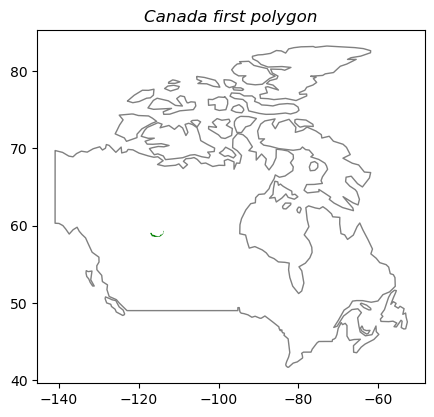

In [79]:
first_polygon = gpd.GeoDataFrame(geodata.iloc[[0]], crs=geodata.crs)
# Plot Canada map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
canada = world[world.name == "Canada"]
ax = canada.plot(color='white', edgecolor='grey', figsize=(5, 5))
# Plot the first polygon
plt.title('Canada first polygon', fontstyle='italic')
first_polygon.plot(ax=ax, color='green')
plt.show()

### Subsetting geodata

In [80]:
geodata_subset = geodata.iloc[:, [0, 1, 38, 39, 40]]
print(geodata_subset.head())

   OBJECTID  SOIL_LANDSCAPE_ID  Shape_Length    Shape_Area  \
0         1           244061.0  1.179293e+06  1.322088e+10   
1         2           244003.0  5.417186e+05  1.352172e+09   
2         3           244007.0  3.126582e+05  4.015173e+09   
3         4           244014.0  1.494326e+05  5.585640e+08   
4         5           244025.0  8.183833e+04  3.119110e+08   

                                            geometry  
0  POLYGON ((-113.74986 59.23671, -113.75026 59.2...  
1  POLYGON ((-122.44083 59.05056, -122.44697 59.0...  
2  POLYGON ((-123.39352 59.17020, -123.39513 59.1...  
3  POLYGON ((-122.55006 58.92013, -122.55402 58.9...  
4  POLYGON ((-122.68475 58.72597, -122.68926 58.7...  


### Check missing values

In [81]:
missing_geodata = geodata_subset.isna()
missing_geodata_counts = missing_geodata.sum()
print(missing_geodata_counts)

OBJECTID               0
SOIL_LANDSCAPE_ID    406
Shape_Length           0
Shape_Area             0
geometry               0
dtype: int64


### Drop rows with missing values

In [82]:
geodata_subset.dropna(subset=['SOIL_LANDSCAPE_ID'], inplace=True)
print(geodata_subset.head())
print(geodata_subset.shape)

   OBJECTID  SOIL_LANDSCAPE_ID  Shape_Length    Shape_Area  \
0         1           244061.0  1.179293e+06  1.322088e+10   
1         2           244003.0  5.417186e+05  1.352172e+09   
2         3           244007.0  3.126582e+05  4.015173e+09   
3         4           244014.0  1.494326e+05  5.585640e+08   
4         5           244025.0  8.183833e+04  3.119110e+08   

                                            geometry  
0  POLYGON ((-113.74986 59.23671, -113.75026 59.2...  
1  POLYGON ((-122.44083 59.05056, -122.44697 59.0...  
2  POLYGON ((-123.39352 59.17020, -123.39513 59.1...  
3  POLYGON ((-122.55006 58.92013, -122.55402 58.9...  
4  POLYGON ((-122.68475 58.72597, -122.68926 58.7...  
(3390, 5)


C:\Users\User\AppData\Local\Temp\ipykernel_30220\2661029010.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  geodata_subset.dropna(subset=['SOIL_LANDSCAPE_ID'], inplace=True)


### Rename columns 

In [83]:
geodata_subset.rename(columns={'SOIL_LANDSCAPE_ID':'ID', 'Shape_Length':'Shape length',
                               'Shape_Area':'Shape area', 'geometry': 'Geometry'}, inplace=True)
geodata_subset.head()

C:\Users\User\AppData\Local\Temp\ipykernel_30220\580053125.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  geodata_subset.rename(columns={'SOIL_LANDSCAPE_ID':'ID', 'Shape_Length':'Shape length',


,OBJECTID,ID,Shape length,Shape area,Geometry
0,1,244061.0,1.179293e+06,1.322088e+10,"POLYGON ((-113.74986 59.23671, -113.75026 59.2..."
1,2,244003.0,5.417186e+05,1.352172e+09,"POLYGON ((-122.44083 59.05056, -122.44697 59.0..."
2,3,244007.0,3.126582e+05,4.015173e+09,"POLYGON ((-123.39352 59.17020, -123.39513 59.1..."
3,4,244014.0,1.494326e+05,5.585640e+08,"POLYGON ((-122.55006 58.92013, -122.55402 58.9..."
4,5,244025.0,8.183833e+04,3.119110e+08,"POLYGON ((-122.68475 58.72597, -122.68926 58.7..."


### Change ID from float to int64

In [84]:
geodata_subset['ID'] = geodata_subset['ID'].astype('int64')
print(geodata_subset.dtypes)

OBJECTID           int64
ID                 int64
Shape length     float64
Shape area       float64
Geometry        geometry
dtype: object


C:\Users\User\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


### Merge dataset to geodata_subset

In [85]:
print(dataset.info())
print(geodata_subset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132331 entries, 0 to 132330
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   ID                       132331 non-null  int64  
 1   Province                 132331 non-null  object 
 2   Year                     132331 non-null  int64  
 3   Polygon weight           132331 non-null  float64
 4   Province %               132331 non-null  float64
 5   PM 10um                  132331 non-null  float64
 6   PM 2.5um                 132331 non-null  float64
 7   PM 100um                 132331 non-null  float64
 8   PM 10um classification   132331 non-null  int64  
 9   PM 10um class            132331 non-null  object 
 10  PM 2.5um classification  132331 non-null  int64  
 11  PM 2.5um class           132331 non-null  object 
 12  PM 100um classification  132331 non-null  int64  
 13  PM 100um class           132331 non-null  object 
dtypes: f

### Add the others geodatasets for PM 2.5um and PM 10um

In [86]:
geodata2 = gpd.read_file(r'C:\Users\User\Desktop\STDA_project\geoJSON\AEI_AIR_PM_25.geojson.txt')
geodata3 = gpd.read_file(r'C:\Users\User\Desktop\STDA_project\geoJSON\AEI_AIR_PM_10.geojson.txt')
print(geodata2.head())
print(geodata2.shape)
print(geodata3.head())
print(geodata3.shape)

   OBJECTID  SOIL_LANDSCAPE_ID  PM25_1981_VAL  PM25_1981_CLASS  \
0         1           244061.0         5.2981              4.0   
1         2           244003.0         0.1736              1.0   
2         3           244007.0         0.1894              1.0   
3         4           244014.0         0.1735              1.0   
4         5           244025.0         0.1737              1.0   

  PM25_1981_CLASS_EN PM25_1981_CLASS_FR  PM25_1986_VAL  PM25_1986_CLASS  \
0               High              Élevé         7.7561              4.0   
1           Very Low        Très faible         0.2931              1.0   
2           Very Low        Très faible         0.3209              1.0   
3           Very Low        Très faible         0.2950              1.0   
4           Very Low        Très faible         0.2896              1.0   

  PM25_1986_CLASS_EN PM25_1986_CLASS_FR  ...  PM25_2016_CLASS  \
0               High              Élevé  ...              2.0   
1           Very Low  

### Apply the same changes from adobe to this 2 geoJSON datasets

In [87]:
geodata2_subset = geodata2.iloc[:, [1, 38, 39, 40]]
print(geodata2_subset.head())
geodata3_subset = geodata3.iloc[:, [1, 38, 39, 40]]
print(geodata3_subset.head())

   SOIL_LANDSCAPE_ID  Shape_Length    Shape_Area  \
0           244061.0  1.179293e+06  1.322088e+10   
1           244003.0  5.417186e+05  1.352172e+09   
2           244007.0  3.126582e+05  4.015173e+09   
3           244014.0  1.494326e+05  5.585640e+08   
4           244025.0  8.183833e+04  3.119110e+08   

                                            geometry  
0  POLYGON ((-113.74986 59.23671, -113.75026 59.2...  
1  POLYGON ((-122.44083 59.05056, -122.44697 59.0...  
2  POLYGON ((-123.39352 59.17020, -123.39513 59.1...  
3  POLYGON ((-122.55006 58.92013, -122.55402 58.9...  
4  POLYGON ((-122.68475 58.72597, -122.68926 58.7...  
   SOIL_LANDSCAPE_ID  Shape_Length    Shape_Area  \
0           244061.0  1.179293e+06  1.322088e+10   
1           244003.0  5.417186e+05  1.352172e+09   
2           244007.0  3.126582e+05  4.015173e+09   
3           244014.0  1.494326e+05  5.585640e+08   
4           244025.0  8.183833e+04  3.119110e+08   

                                            

In [88]:
geodata2_subset.rename(columns={'SOIL_LANDSCAPE_ID':'ID', 'Shape_Length':'Shape length',
                               'Shape_Area':'Shape area', 'geometry': 'Geometry'}, inplace=True)
geodata2_subset.head()

C:\Users\User\AppData\Local\Temp\ipykernel_30220\4008801716.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  geodata2_subset.rename(columns={'SOIL_LANDSCAPE_ID':'ID', 'Shape_Length':'Shape length',


,ID,Shape length,Shape area,Geometry
0,244061.0,1.179293e+06,1.322088e+10,"POLYGON ((-113.74986 59.23671, -113.75026 59.2..."
1,244003.0,5.417186e+05,1.352172e+09,"POLYGON ((-122.44083 59.05056, -122.44697 59.0..."
2,244007.0,3.126582e+05,4.015173e+09,"POLYGON ((-123.39352 59.17020, -123.39513 59.1..."
3,244014.0,1.494326e+05,5.585640e+08,"POLYGON ((-122.55006 58.92013, -122.55402 58.9..."
4,244025.0,8.183833e+04,3.119110e+08,"POLYGON ((-122.68475 58.72597, -122.68926 58.7..."


In [89]:
geodata3_subset.rename(columns={'SOIL_LANDSCAPE_ID':'ID', 'Shape_Length':'Shape length',
                               'Shape_Area':'Shape area', 'geometry': 'Geometry'}, inplace=True)
geodata3_subset.head()

C:\Users\User\AppData\Local\Temp\ipykernel_30220\138935556.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  geodata3_subset.rename(columns={'SOIL_LANDSCAPE_ID':'ID', 'Shape_Length':'Shape length',


,ID,Shape length,Shape area,Geometry
0,244061.0,1.179293e+06,1.322088e+10,"POLYGON ((-113.74986 59.23671, -113.75026 59.2..."
1,244003.0,5.417186e+05,1.352172e+09,"POLYGON ((-122.44083 59.05056, -122.44697 59.0..."
2,244007.0,3.126582e+05,4.015173e+09,"POLYGON ((-123.39352 59.17020, -123.39513 59.1..."
3,244014.0,1.494326e+05,5.585640e+08,"POLYGON ((-122.55006 58.92013, -122.55402 58.9..."
4,244025.0,8.183833e+04,3.119110e+08,"POLYGON ((-122.68475 58.72597, -122.68926 58.7..."


In [90]:
geodata2_subset.dropna(subset=['ID'], inplace=True)
print(geodata2_subset.head())
print(geodata2_subset.shape)

         ID  Shape length    Shape area  \
0  244061.0  1.179293e+06  1.322088e+10   
1  244003.0  5.417186e+05  1.352172e+09   
2  244007.0  3.126582e+05  4.015173e+09   
3  244014.0  1.494326e+05  5.585640e+08   
4  244025.0  8.183833e+04  3.119110e+08   

                                            Geometry  
0  POLYGON ((-113.74986 59.23671, -113.75026 59.2...  
1  POLYGON ((-122.44083 59.05056, -122.44697 59.0...  
2  POLYGON ((-123.39352 59.17020, -123.39513 59.1...  
3  POLYGON ((-122.55006 58.92013, -122.55402 58.9...  
4  POLYGON ((-122.68475 58.72597, -122.68926 58.7...  
(3390, 4)


C:\Users\User\AppData\Local\Temp\ipykernel_30220\3185737316.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  geodata2_subset.dropna(subset=['ID'], inplace=True)


In [91]:
geodata3_subset.dropna(subset=['ID'], inplace=True)
print(geodata3_subset.head())
print(geodata3_subset.shape)

         ID  Shape length    Shape area  \
0  244061.0  1.179293e+06  1.322088e+10   
1  244003.0  5.417186e+05  1.352172e+09   
2  244007.0  3.126582e+05  4.015173e+09   
3  244014.0  1.494326e+05  5.585640e+08   
4  244025.0  8.183833e+04  3.119110e+08   

                                            Geometry  
0  POLYGON ((-113.74986 59.23671, -113.75026 59.2...  
1  POLYGON ((-122.44083 59.05056, -122.44697 59.0...  
2  POLYGON ((-123.39352 59.17020, -123.39513 59.1...  
3  POLYGON ((-122.55006 58.92013, -122.55402 58.9...  
4  POLYGON ((-122.68475 58.72597, -122.68926 58.7...  
(3390, 4)


C:\Users\User\AppData\Local\Temp\ipykernel_30220\1411299430.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  geodata3_subset.dropna(subset=['ID'], inplace=True)


In [92]:
geodata2_subset['ID'] = geodata2_subset['ID'].astype('int64')
print(geodata2_subset.dtypes)
geodata3_subset['ID'] = geodata3_subset['ID'].astype('int64')
print(geodata3_subset.dtypes)

ID                 int64
Shape length     float64
Shape area       float64
Geometry        geometry
dtype: object
ID                 int64
Shape length     float64
Shape area       float64
Geometry        geometry
dtype: object


C:\Users\User\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\User\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


### Concatenate all geodatafiles (There are 3 geofiles in total)

In [93]:
print(geodata_subset.shape)
print(geodata2_subset.shape)
print(geodata3_subset.shape)

(3390, 5)
(3390, 4)
(3390, 4)


In [94]:
concatenated_geodata = pd.concat([geodata_subset, geodata2_subset, geodata3_subset], ignore_index=True)
print(concatenated_geodata.head())
print(concatenated_geodata.shape)

   OBJECTID      ID  Shape length    Shape area  \
0       1.0  244061  1.179293e+06  1.322088e+10   
1       2.0  244003  5.417186e+05  1.352172e+09   
2       3.0  244007  3.126582e+05  4.015173e+09   
3       4.0  244014  1.494326e+05  5.585640e+08   
4       5.0  244025  8.183833e+04  3.119110e+08   

                                            Geometry  
0  POLYGON ((-113.74986 59.23671, -113.75026 59.2...  
1  POLYGON ((-122.44083 59.05056, -122.44697 59.0...  
2  POLYGON ((-123.39352 59.17020, -123.39513 59.1...  
3  POLYGON ((-122.55006 58.92013, -122.55402 58.9...  
4  POLYGON ((-122.68475 58.72597, -122.68926 58.7...  
(10170, 5)


### Reset index in concatenated geodata

In [95]:
concatenated_geodata.reset_index(drop=True, inplace=True)
print(concatenated_geodata.head())
print(concatenated_geodata.shape)

   OBJECTID      ID  Shape length    Shape area  \
0       1.0  244061  1.179293e+06  1.322088e+10   
1       2.0  244003  5.417186e+05  1.352172e+09   
2       3.0  244007  3.126582e+05  4.015173e+09   
3       4.0  244014  1.494326e+05  5.585640e+08   
4       5.0  244025  8.183833e+04  3.119110e+08   

                                            Geometry  
0  POLYGON ((-113.74986 59.23671, -113.75026 59.2...  
1  POLYGON ((-122.44083 59.05056, -122.44697 59.0...  
2  POLYGON ((-123.39352 59.17020, -123.39513 59.1...  
3  POLYGON ((-122.55006 58.92013, -122.55402 58.9...  
4  POLYGON ((-122.68475 58.72597, -122.68926 58.7...  
(10170, 5)


### Check only for unique ID values

#### This is a important part of the project. This is done because the geoJSON files were different for each PM measurement.
#### When the merge is done, the new file contains reapeted polygons ID coming for the 3 individual files.
#### The filter for unique ID values allows the identification of each polygon geolocalization with its corresponding ID.

In [99]:
concatenated_geodata_unique = concatenated_geodata.drop_duplicates(subset=['ID'])
print(concatenated_geodata_unique.head())
print(concatenated_geodata_unique.shape)

   OBJECTID      ID  Shape length    Shape area  \
0       1.0  244061  1.179293e+06  1.322088e+10   
1       2.0  244003  5.417186e+05  1.352172e+09   
2       3.0  244007  3.126582e+05  4.015173e+09   
3       4.0  244014  1.494326e+05  5.585640e+08   
4       5.0  244025  8.183833e+04  3.119110e+08   

                                            Geometry  
0  POLYGON ((-113.74986 59.23671, -113.75026 59.2...  
1  POLYGON ((-122.44083 59.05056, -122.44697 59.0...  
2  POLYGON ((-123.39352 59.17020, -123.39513 59.1...  
3  POLYGON ((-122.55006 58.92013, -122.55402 58.9...  
4  POLYGON ((-122.68475 58.72597, -122.68926 58.7...  
(3390, 5)


In [100]:
duplicated_ids = geodata_subset[geodata_subset.duplicated(subset=['ID'], keep=False)]
print(duplicated_ids)

Empty GeoDataFrame
Columns: [OBJECTID, ID, Shape length, Shape area, Geometry]
Index: []


### Merge dataset with concatenated geodata

#### In this part the merged is done between the data file containg the particulate matter measurements and the concatenated
#### file with the geolocation of each polygon ID. Now it is possible to visualize in a map the location of each ID number
#### to understand where the PM measures have been taken.

In [103]:
print(dataset.shape)
print(concatenated_geodata_unique.shape)
print(dataset.head(2))

(132331, 14)
(3390, 5)
       ID Province  Year  Polygon weight  Province %  PM 10um  PM 2.5um  \
0  244061       AB  1981        1402.550       100.0   11.861    5.2981   
1  244070       AB  1981         303.552       100.0    1.041    0.2264   

   PM 100um  PM 10um classification PM 10um class  PM 2.5um classification  \
0    52.827                       3      Moderate                        4   
1     2.245                       1      Very Low                        1   

  PM 2.5um class  PM 100um classification PM 100um class  
0           High                        4           High  
1       Very Low                        1       Very Low  


In [104]:
merged_data = pd.merge(dataset, concatenated_geodata_unique[['ID', 'Shape length', 'Shape area', 'Geometry']], on='ID', how='left')
print(merged_data.head())
print(merged_data.shape)

       ID Province  Year  Polygon weight  Province %  PM 10um  PM 2.5um  \
0  244061       AB  1981        1402.550       100.0   11.861    5.2981   
1  244070       AB  1981         303.552       100.0    1.041    0.2264   
2  583011       AB  1981         162.279       100.0    2.330    0.4288   
3  583013       AB  1981        1450.270        54.0    9.339    3.7604   
4  583018       AB  1981         125.109       100.0    2.077    0.3900   

   PM 100um  PM 10um classification PM 10um class  PM 2.5um classification  \
0    52.827                       3      Moderate                        4   
1     2.245                       1      Very Low                        1   
2     4.990                       1      Very Low                        1   
3    38.302                       2           Low                        3   
4     4.486                       1      Very Low                        1   

  PM 2.5um class  PM 100um classification PM 100um class  Shape length  \
0     

## Input weather data

#### Then, the last dataset is the temperature data. This file contains temperature measurements data taken from a specific
#### wheather station in Canada. The file shows temperature measures among years till 2015 and then projections of 
#### temperature measurements according to 3 different environmental scenarios.
#### The challenge here is to correlate the location of this weather station with the correct polygon ID in order to analyze 
#### data from particulate matter measurements with the temperature in the same location.

### Max temperature dataset from climatedata.ca

#### This is the temperature dataset having temperature measurements and predictions in 3 possible environmental scenarios called Shraed Socioeconomic Pathways or SSP. These pathways are part of a set of scenarios used by the Intergovernmental Panel on Climate Change (IPCC) to explore potential future socioeconomic and environmental developments. These scenarios are used in climate modeling to explore how different policy decisions and social trends might influence future air pollutants emissions and climate change impacts.
####
#### ssp126: Low challenges to mitigation and adaptation. In this scenario, there is strong international cooperation to address environmental and social challenges, leading to a relatively sustainable and equitable future.
#### 
#### ssp245: Intermediate challenges to mitigation and adaptation. In this scenario, there is some international cooperation, but also significant social and economic inequalities and environmental degradation.
####
#### ssp585: High challenges to mitigation and adaptation. In this scenario,  there is limited international cooperation and significant environmental degradation, leading to substantial climate change impacts and societal disruptions.

#### The data contains the percentiles 10, 50 and 90 for each possible scenario.

In [395]:
file_path = '/Users/User/Desktop/STDA_project/Weather/temperature_max.csv'
temp_max= pd.read_csv(file_path, encoding='latin-1')
print(temp_max.shape)
print(temp_max.head())
print(temp_max.info())

(151, 12)
       time        lat         lon  ssp126_tx_mean_p10  ssp126_tx_mean_p50  \
0  1/1/1950  49.041666 -122.291667               13.37               14.47   
1  1/1/1951  49.041666 -122.291667               13.21               13.96   
2  1/1/1952  49.041666 -122.291667               13.55               14.31   
3  1/1/1953  49.041666 -122.291667               13.35               14.37   
4  1/1/1954  49.041666 -122.291667               13.39               14.30   

   ssp126_tx_mean_p90  ssp245_tx_mean_p10  ssp245_tx_mean_p50  \
0               15.33               13.37               14.47   
1               14.98               13.21               13.96   
2               14.94               13.55               14.31   
3               14.88               13.35               14.37   
4               15.54               13.39               14.30   

   ssp245_tx_mean_p90  ssp585_tx_mean_p10  ssp585_tx_mean_p50  \
0               15.33               13.37               14.47   


### Subset temp_max dataset for period 1980-2018

#### The temperature subset is needed in the period 1980-2018. This is donde to analyze the same period of time
#### according to the particulate matter measures. The rest of the values were dropped.

In [271]:
print(dataset.tail())

            ID Province  Year  Polygon weight  Province %  PM 10um  PM 2.5um  \
132326  838013       SK  2018       51779.640       100.0    0.218    0.0637   
132327  838014       SK  2018        4658.010        55.0    0.324    0.0947   
132328  838015       SK  2018       62134.526       100.0    1.732    0.5588   
132329  838016       SK  2018        1416.340        12.9    0.510    0.2290   
132330  838017       SK  2018       19108.746        30.9    0.374    0.1514   

        PM 100um  PM 10um classification PM 10um class  \
132326     0.488                       1      Very Low   
132327     0.695                       1      Very Low   
132328     4.640                       1      Very Low   
132329     1.693                       1      Very Low   
132330     1.374                       1      Very Low   

        PM 2.5um classification PM 2.5um class  PM 100um classification  \
132326                        1       Very Low                        1   
132327              

In [272]:
temp_max['time'] = pd.to_datetime(temp_max['time'])
temp_max_subset = temp_max[(temp_max['time'].dt.year >= 1990) & (temp_max['time'].dt.year <= 2019)]
print(temp_max_subset)

         time        lat         lon  ssp126_tx_mean_p10  ssp126_tx_mean_p50  \
40 1990-01-01  49.041666 -122.291667               13.48               14.87   
41 1991-01-01  49.041666 -122.291667               13.60               14.59   
42 1992-01-01  49.041666 -122.291667               13.24               14.22   
43 1993-01-01  49.041666 -122.291667               12.93               14.11   
44 1994-01-01  49.041666 -122.291667               13.44               14.49   
45 1995-01-01  49.041666 -122.291667               13.22               14.34   
46 1996-01-01  49.041666 -122.291667               13.24               14.37   
47 1997-01-01  49.041666 -122.291667               13.21               14.39   
48 1998-01-01  49.041666 -122.291667               13.89               14.75   
49 1999-01-01  49.041666 -122.291667               13.71               14.73   
50 2000-01-01  49.041666 -122.291667               13.81               14.70   
51 2001-01-01  49.041666 -122.291667    

### Select those polygons ID which falls into temp_max_subset latitud and longitud

#### Now it is important to select only those polygons ID that have the same location of the weather station. This is done in
#### order to compare the temperature measures with the particulate measures in the same year and same location.

In [273]:
import geopandas as gpd
from shapely.geometry import Point
# Convert latitudes and longitudes from the temperature dataset to Point geometries
temperature_points = [Point(lon, lat) for lon, lat in zip(temp_max_subset['lon'], temp_max_subset['lat'])]
# Create a GeoDataFrame from temperature points
temperature_gdf = gpd.GeoDataFrame(temp_max_subset, geometry=temperature_points, crs='EPSG:4326')
# Convert the merged_data df to a GeoDataFrame with the appropriate geometry column
merged_data_gdf = gpd.GeoDataFrame(merged_data, geometry='Geometry')
# Perform a spatial join between temperature points and polygons in merged_data
merged_filtered = gpd.sjoin(temperature_gdf, merged_data_gdf, op='within')
# Extract the IDs of polygons that contain the temperature points
selected_ids = merged_filtered['ID'].unique()
# Filter the original merged_data DataFrame to include only the selected IDs
merged_data_filtered = merged_data[merged_data['ID'].isin(selected_ids)]
print(merged_data_filtered.head())
print(merged_data_filtered.shape)

           ID Province  Year  Polygon weight  Province %  PM 10um  PM 2.5um  \
772    959020       BC  1981        4965.254       100.0   21.858    7.9753   
4254   959020       BC  1982        4843.950       100.0   22.226    8.1077   
7736   959020       BC  1983        4722.700       100.0   22.583    8.2416   
11218  959020       BC  1984        4601.406       100.0   22.977    8.3707   
14700  959020       BC  1985        4480.156       100.0   23.304    8.4747   

       PM 100um  PM 10um classification PM 10um class  \
772     123.033                       4          High   
4254    125.250                       4          High   
7736    127.546                       4          High   
11218   130.062                       4          High   
14700   132.563                       4          High   

       PM 2.5um classification PM 2.5um class  PM 100um classification  \
772                          4           High                        5   
4254                         5    

C:\Users\User\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3466: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


### Merging of merged_data_filtered and temp_max_subset 

In [274]:
print(merged_data_filtered.head())
print(temp_max_subset.head())

           ID Province  Year  Polygon weight  Province %  PM 10um  PM 2.5um  \
772    959020       BC  1981        4965.254       100.0   21.858    7.9753   
4254   959020       BC  1982        4843.950       100.0   22.226    8.1077   
7736   959020       BC  1983        4722.700       100.0   22.583    8.2416   
11218  959020       BC  1984        4601.406       100.0   22.977    8.3707   
14700  959020       BC  1985        4480.156       100.0   23.304    8.4747   

       PM 100um  PM 10um classification PM 10um class  \
772     123.033                       4          High   
4254    125.250                       4          High   
7736    127.546                       4          High   
11218   130.062                       4          High   
14700   132.563                       4          High   

       PM 2.5um classification PM 2.5um class  PM 100um classification  \
772                          4           High                        5   
4254                         5    

### Change time columns to keep only year and rename it

In [275]:
# Convert 'time' column to datetime and extract the year
temp_max_subset['Year'] = pd.to_datetime(temp_max_subset['time']).dt.year
# Drop the original 'time' column
temp_max_subset.drop(columns=['time'], inplace=True)
print(temp_max_subset.head())

          lat         lon  ssp126_tx_mean_p10  ssp126_tx_mean_p50  \
40  49.041666 -122.291667               13.48               14.87   
41  49.041666 -122.291667               13.60               14.59   
42  49.041666 -122.291667               13.24               14.22   
43  49.041666 -122.291667               12.93               14.11   
44  49.041666 -122.291667               13.44               14.49   

    ssp126_tx_mean_p90  ssp245_tx_mean_p10  ssp245_tx_mean_p50  \
40               16.26               13.48               14.87   
41               15.35               13.60               14.59   
42               15.18               13.24               14.22   
43               15.37               12.93               14.11   
44               15.15               13.44               14.49   

    ssp245_tx_mean_p90  ssp585_tx_mean_p10  ssp585_tx_mean_p50  \
40               16.26               13.48               14.87   
41               15.35               13.60              

C:\Users\User\AppData\Local\Temp\ipykernel_30220\3399876685.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_max_subset['Year'] = pd.to_datetime(temp_max_subset['time']).dt.year
C:\Users\User\AppData\Local\Temp\ipykernel_30220\3399876685.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_max_subset.drop(columns=['time'], inplace=True)


### Merged tables 

In [279]:
print(temp_max_subset.shape)
print(temp_max_subset['Year'])

(30, 12)
40    1990
41    1991
42    1992
43    1993
44    1994
45    1995
46    1996
47    1997
48    1998
49    1999
50    2000
51    2001
52    2002
53    2003
54    2004
55    2005
56    2006
57    2007
58    2008
59    2009
60    2010
61    2011
62    2012
63    2013
64    2014
65    2015
66    2016
67    2017
68    2018
69    2019
Name: Year, dtype: int32


In [280]:
print(merged_data_filtered['Year'])

772       1981
4254      1982
7736      1983
11218     1984
14700     1985
18182     1986
21664     1987
25146     1988
28628     1989
32110     1990
35592     1991
39074     1992
42556     1993
46038     1994
49520     1995
53002     1996
56484     1997
59966     1998
63448     1999
66930     2000
70412     2001
73895     2002
77378     2003
80861     2004
84344     2005
87827     2006
91310     2007
94793     2008
98276     2009
101759    2010
105242    2011
108725    2012
112208    2013
115691    2014
119174    2015
122657    2016
126139    2017
129621    2018
Name: Year, dtype: int64


### Merged on year for ID 959020

#### As mentioned before, the weather station falls in the polygon ID 959020. Now it is possible to have all data together and
#### analyze trends on the data over time. This ID corresponds to Abbotsford in British Columbia.

In [397]:
measure_and_temp = pd.merge(merged_data_filtered, temp_max_subset, on='Year', how='inner')
print(measure_and_temp)
print(measure_and_temp.info())

        ID Province  Year  Polygon weight  Province %  PM 10um  PM 2.5um  \
0   959020       BC  1990        3873.793       100.0   28.825    9.8094   
1   959020       BC  1991        3805.506       100.0   29.859    9.9846   
2   959020       BC  1992        3732.484       100.0   30.558   10.2805   
3   959020       BC  1993        3659.509       100.0   31.311   10.5565   
4   959020       BC  1994        3586.492       100.0   32.163   10.8806   
5   959020       BC  1995        3513.493       100.0   33.047   11.2349   
6   959020       BC  1996        3440.472       100.0   33.856   11.5188   
7   959020       BC  1997        3373.649       100.0   33.929   11.5307   
8   959020       BC  1998        3306.804       100.0   33.916   11.5286   
9   959020       BC  1999        3239.990       100.0   33.913   11.5177   
10  959020       BC  2000        3173.179       100.0   33.858   11.4755   
11  959020       BC  2001        3170.187       100.0   33.458   11.3170   
12  959020  

### The final output is the following file:

In [398]:
# Print the measure_and_temp df
measure_and_temp.to_excel('measure_and_temp.xlsx', index=False)

# Part II: Data exploration

#### In this part of the project, the inputs and output data files are explored to find data patterns and insights.
#### In the data inputs, the particulate matter measurements file, the concatenated geoJSON file and the temperature
#### files are used to create visuals of those data. 
#### Related to the output part, the measure_and_temp final file is used to chart and understand the data trends. 

## Data exploration: Input data insights

### Select sns style and pallette

In [137]:
sns.set_style("white")
colors = sns.color_palette("bright")
print(colors)

[(0.00784313725490196, 0.24313725490196078, 1.0), (1.0, 0.48627450980392156, 0.0), (0.10196078431372549, 0.788235294117647, 0.2196078431372549), (0.9098039215686274, 0.0, 0.043137254901960784), (0.5450980392156862, 0.16862745098039217, 0.8862745098039215), (0.6235294117647059, 0.2823529411764706, 0.0), (0.9450980392156862, 0.2980392156862745, 0.7568627450980392), (0.6392156862745098, 0.6392156862745098, 0.6392156862745098), (1.0, 0.7686274509803922, 0.0), (0.0, 0.8431372549019608, 1.0)]


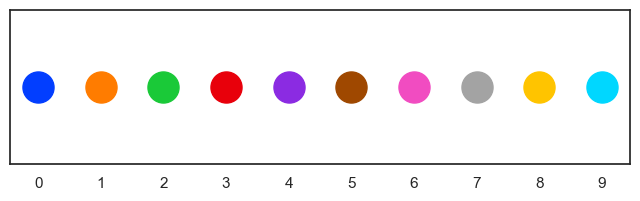

In [138]:
rgb_colors = [(0.00784313725490196, 0.24313725490196078, 1.0), (1.0, 0.48627450980392156, 0.0),
          (0.10196078431372549, 0.788235294117647, 0.2196078431372549), (0.9098039215686274, 0.0, 0.043137254901960784),
          (0.5450980392156862, 0.16862745098039217, 0.8862745098039215), (0.6235294117647059, 0.2823529411764706, 0.0), 
          (0.9450980392156862, 0.2980392156862745, 0.7568627450980392), (0.6392156862745098, 0.6392156862745098, 0.6392156862745098),
          (1.0, 0.7686274509803922, 0.0), (0.0, 0.8431372549019608, 1.0)]
hex_colors = ['#%02x%02x%02x' % (int(r * 255), int(g * 255), int(b * 255)) for r, g, b in rgb_colors]
plt.figure(figsize=(8, 2))
for i, color in enumerate(hex_colors):
    plt.scatter(i, 0, color=color, s=500)

plt.xticks(range(len(hex_colors)))
plt.yticks([])
plt.show()

### Input data: PM measures Boxplot 

#### Define provinces order 

In [139]:
province_order = merged_data['Province'].unique()
print(province_order)

['AB' 'BC' 'MB' 'NB' 'NF' 'NS' 'ON' 'PE' 'QC' 'SK']


#### Merged data df

In [400]:
print(merged_data)

            ID Province  Year  Polygon weight  Province %  PM 10um  PM 2.5um  \
0       244061       AB  1981        1402.550       100.0   11.861    5.2981   
1       244070       AB  1981         303.552       100.0    1.041    0.2264   
2       583011       AB  1981         162.279       100.0    2.330    0.4288   
3       583013       AB  1981        1450.270        54.0    9.339    3.7604   
4       583018       AB  1981         125.109       100.0    2.077    0.3900   
...        ...      ...   ...             ...         ...      ...       ...   
132326  838013       SK  2018       51779.640       100.0    0.218    0.0637   
132327  838014       SK  2018        4658.010        55.0    0.324    0.0947   
132328  838015       SK  2018       62134.526       100.0    1.732    0.5588   
132329  838016       SK  2018        1416.340        12.9    0.510    0.2290   
132330  838017       SK  2018       19108.746        30.9    0.374    0.1514   

        PM 100um  PM 10um classificatio

#### Create Boxplots in same figure

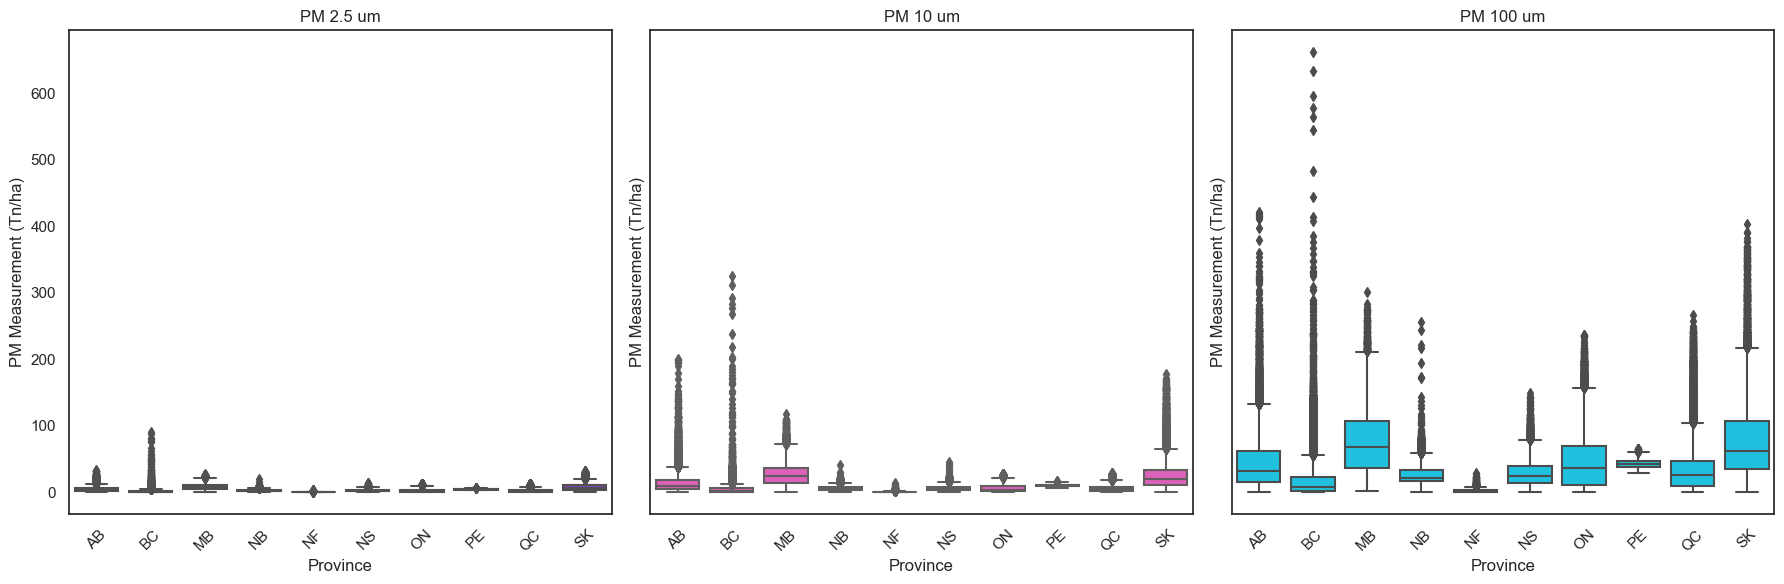

In [152]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
# Plot each PM measurement on a separate subplot
sns.boxplot(ax=axes[0], x='Province', y='PM 2.5um', data=merged_data, order=province_order, color=colors[4])
sns.boxplot(ax=axes[1], x='Province', y='PM 10um', data=merged_data, order=province_order, color=colors[6])
sns.boxplot(ax=axes[2], x='Province', y='PM 100um', data=merged_data, order=province_order, color=colors[9])
# Set titles and labels
axes[0].set_title('PM 2.5 um')
axes[1].set_title('PM 10 um')
axes[2].set_title('PM 100 um')
for ax in axes:
    ax.set_xlabel('Province')
    ax.set_ylabel('PM Measurement (Tn/ha)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

### Input data: Time series plots

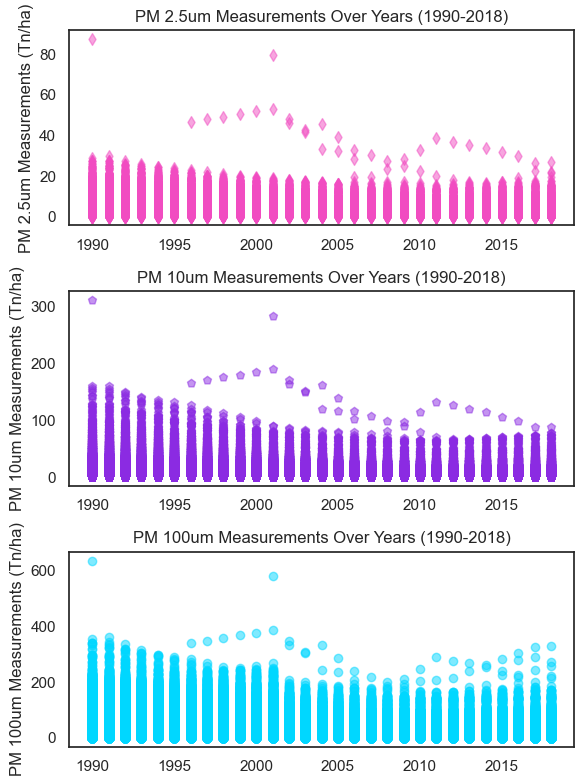

In [425]:
sns.set_style("white")
colors = sns.color_palette("bright")
# Filter data for years 1990 to 2018
merged_data_filtered = merged_data[(merged_data['Year'] >= 1990) & (merged_data['Year'] <= 2018)]
# Plotting each PM type in separate subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 8)) 
# Plot PM 2.5um
axes[0].scatter(merged_data_filtered['Year'], merged_data_filtered['PM 2.5um'], marker='d', color=colors[6], alpha=0.5)
axes[0].set_ylabel('PM 2.5um Measurements (Tn/ha)')  
axes[0].set_title('PM 2.5um Measurements Over Years (1990-2018)')
# Plot PM 10um
axes[1].scatter(merged_data_filtered['Year'], merged_data_filtered['PM 10um'], marker='p', color=colors[4], alpha=0.5)
axes[1].set_ylabel('PM 10um Measurements (Tn/ha)')  
axes[1].set_title('PM 10um Measurements Over Years (1990-2018)')
# Plot PM 100um
axes[2].scatter(merged_data_filtered['Year'], merged_data_filtered['PM 100um'], marker='o', color=colors[9], alpha=0.5)
axes[2].set_ylabel('PM 100um Measurements (Tn/ha)')  
axes[2].set_title('PM 100um Measurements Over Years (1990-2018)')
plt.tight_layout()
plt.show()

#### Plotting grouping by years and calculating the mean can give us an overall tendency of the PM measurements

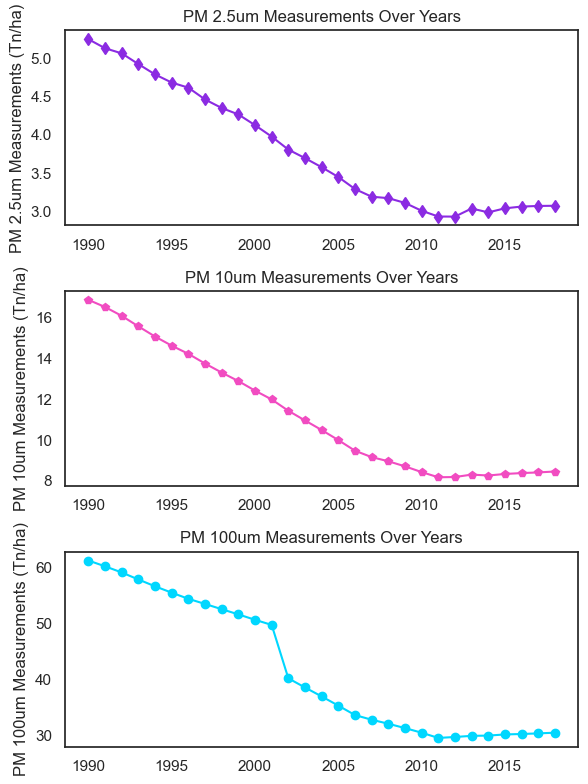

In [422]:
sns.set_style("white")
colors = sns.color_palette("bright")
# Grouping filtered data by 'Year' and calculating mean PM values
pm_yearly_mean = merged_data_filtered.groupby('Year')[['PM 2.5um', 'PM 10um', 'PM 100um']].mean()
# Plotting each PM type in separate subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 8))  
# Plot PM 2.5um
axes[0].plot(pm_yearly_mean.index, pm_yearly_mean['PM 2.5um'], marker='d', color=colors[4])
axes[0].set_ylabel('PM 2.5um Measurements (Tn/ha)') 
axes[0].set_title('PM 2.5um Measurements Over Years')
# Plot PM 10um
axes[1].plot(pm_yearly_mean.index, pm_yearly_mean['PM 10um'], marker='p', color=colors[6])
axes[1].set_ylabel('PM 10um Measurements (Tn/ha)')  
axes[1].set_title('PM 10um Measurements Over Years')
# Plot PM 100um
axes[2].plot(pm_yearly_mean.index, pm_yearly_mean['PM 100um'], marker='o', color=colors[9])
axes[2].set_ylabel('PM 100um Measurements (Tn/ha)')  
axes[2].set_title('PM 100um Measurements Over Years')
plt.tight_layout()
plt.show()

### Input data: GeoJSON files - Polygons visualization

#### The polygons on the map look like the image bellow

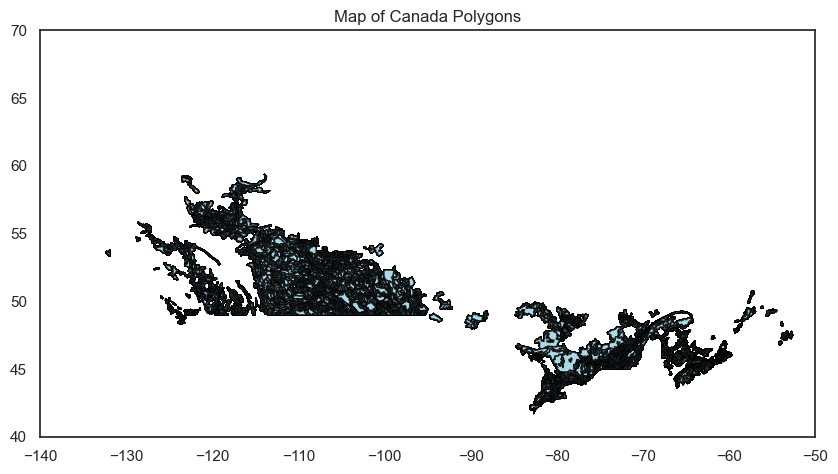

In [427]:
gdf = gpd.GeoDataFrame(merged_data, geometry='Geometry')
# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(10, 10))
# Set extent to focus on Canada
ax.set_xlim(-140, -50)  # longitude range for Canada
ax.set_ylim(40, 70)     # latitude range for Canada
gdf.plot(ax=ax, edgecolor='black', facecolor='lightblue', alpha=0.7)
ax.set_title('Map of Canada Polygons')
plt.show()

### Create cloropleth maps

#### Now that have seen the huge amount of polygons, it is better to not to plot the polygons borders and visualize each PM measure
#### in a gradient of colours. Here it is easy to see which locations across Canada are measure low, medium and high air 
#### pollutants. 

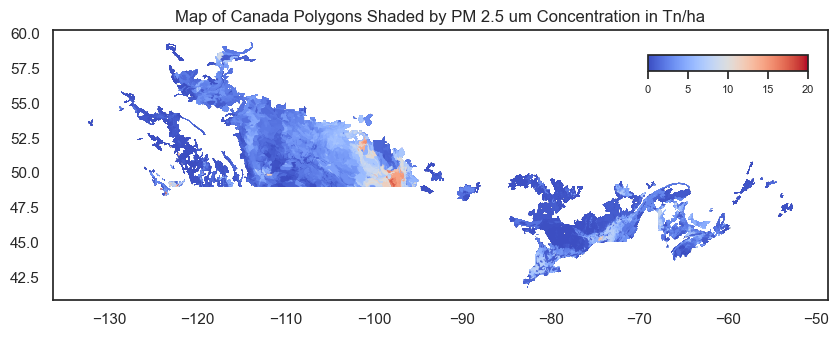

In [205]:
gdf = gpd.GeoDataFrame(merged_data, geometry='Geometry')
fig, ax = plt.subplots(figsize=(10, 8))
# Define the range for the legend scale
vmin = 0 
vmax = 20  
# Plot the geometry data with shading based on PM 2.5um concentration
gdf.plot(ax=ax, column='PM 2.5um', cmap='coolwarm', edgecolor='none', linewidth=0.5, legend=False, vmin=vmin, vmax=vmax)
# Plot the geometry column (boundaries only)
gdf.boundary.plot(ax=ax, color='none')
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []  
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.2, aspect=10, pad=0.05)
cbar.ax.set_position([0.55, 0.55, 0.5, 0.02]) 
cbar.ax.tick_params(labelsize=8)
ax.set_title('Map of Canada Polygons Shaded by PM 2.5 um Concentration in Tn/ha')
plt.show()

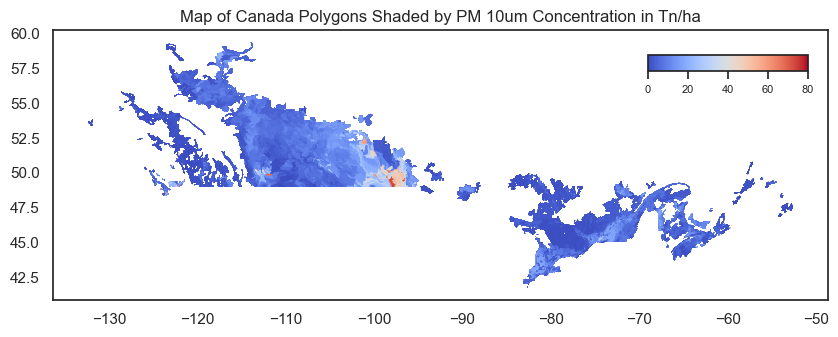

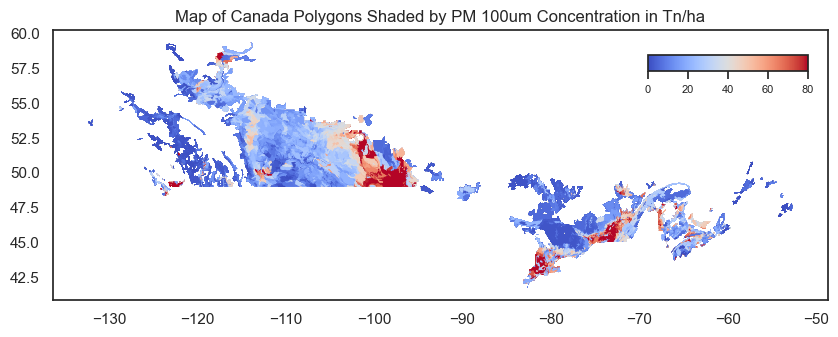

In [450]:
sns.set_style("white")
colors = sns.color_palette("bright")
# Filter the data
gdf = gpd.GeoDataFrame(merged_data, geometry='Geometry')
# Define the range for the legend scale
vmin = 0 
vmax = 80  
# Plotting PM 10um concentrations
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(ax=ax, column='PM 10um', cmap='coolwarm', edgecolor='none', linewidth=0.5, legend=False, vmin=vmin, vmax=vmax)
gdf.boundary.plot(ax=ax, color='none')
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []  # Fake empty array for the colorbar
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.2, aspect=10, pad=0.05)
cbar.ax.set_position([0.55, 0.55, 0.5, 0.02]) 
cbar.ax.tick_params(labelsize=8)
ax.set_title('Map of Canada Polygons Shaded by PM 10um Concentration in Tn/ha')
# Plotting PM 100um concentrations
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(ax=ax, column='PM 100um', cmap='coolwarm', edgecolor='none', linewidth=0.5, legend=False, vmin=vmin, vmax=vmax)
gdf.boundary.plot(ax=ax, color='none')
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []  
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.2, aspect=10, pad=0.05)
cbar.ax.set_position([0.55, 0.55, 0.5, 0.02]) 
cbar.ax.tick_params(labelsize=8)
ax.set_title('Map of Canada Polygons Shaded by PM 100um Concentration in Tn/ha')
plt.show()

#### As it is shown bellow, plotting the polygons delimitations (borders) cause problems when trying to identify the 
#### areas with differents PM concentrations.

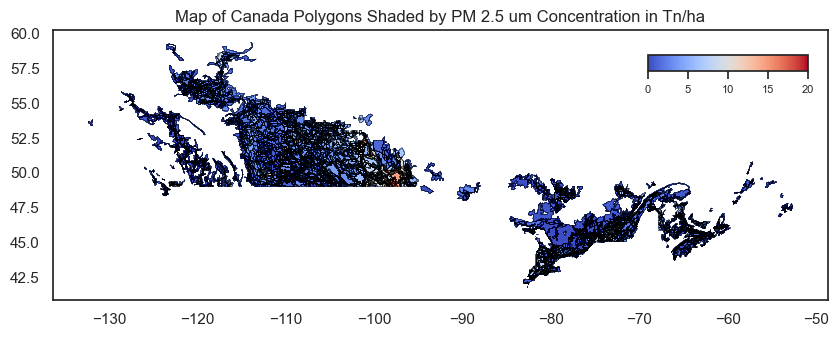

In [209]:
gdf = gpd.GeoDataFrame(merged_data, geometry='Geometry')
fig, ax = plt.subplots(figsize=(10, 8))
# Define the range for the legend scale
vmin = 0  
vmax = 20  
# Plot the geometry data with shading based on PM 2.5um concentration
gdf.plot(ax=ax, column='PM 2.5um', cmap='coolwarm', edgecolor='none', linewidth=0.5, legend=False, vmin=vmin, vmax=vmax)
# Plot the geometry column (boundaries only)
gdf.boundary.plot(ax=ax, color='black', linewidth=0.01)  
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []  
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.2, aspect=10, pad=0.05)
cbar.ax.set_position([0.55, 0.55, 0.5, 0.02])  
cbar.ax.tick_params(labelsize=8)
ax.set_title('Map of Canada Polygons Shaded by PM 2.5 um Concentration in Tn/ha')
plt.show()

#### Another important tool is to plot the polygons on a Canada political map. As it is seen in the imaage bellow. 
#### Here is easy to identify regions across the country but there is huge empty space in the map. 

C:\Users\User\AppData\Local\Temp\ipykernel_30220\194404912.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


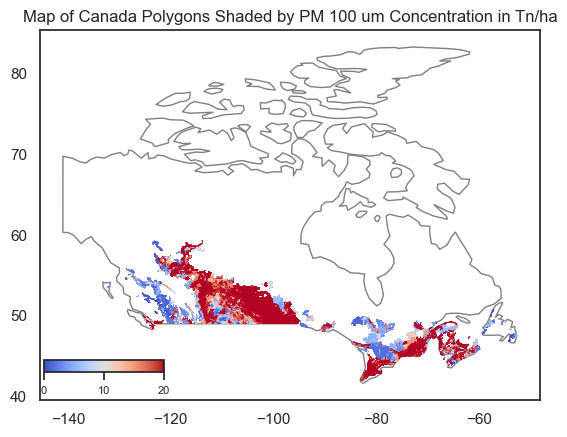

In [449]:
# Load the world map and extract Canada
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
canada = world[world.name == "Canada"]
gdf = gpd.GeoDataFrame(merged_data, geometry='Geometry')
fig, ax = plt.subplots(figsize=(8, 6))
# Define the range for the legend scale
vmin = 0  
vmax = 20  
# Plot the map of Canada
canada.plot(ax=ax, color='none', edgecolor='gray', linewidth=1)
# Plot the geometry data with shading based on PM 2.5 um concentration
gdf.plot(ax=ax, column='PM 100um', cmap='coolwarm', edgecolor='none', linewidth=0.5, legend=False, vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []  
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.2, aspect=10, pad=0.05)
cbar.ax.set_position([0.03, 0.31, 0.5, 0.02])  
cbar.ax.tick_params(labelsize=8)
ax.set_title('Map of Canada Polygons Shaded by PM 100 um Concentration in Tn/ha')
plt.show()

### Input data: Temperature and scenarios

#### As mentioned before there are data from 3 different environmental scenarios. 
#### And also the data contains p10, p50 and p90 percentiles of temperaturtes for each scenario.
#### It is important to see how these data looks like.

#### Temperature over the years in differents scenarios

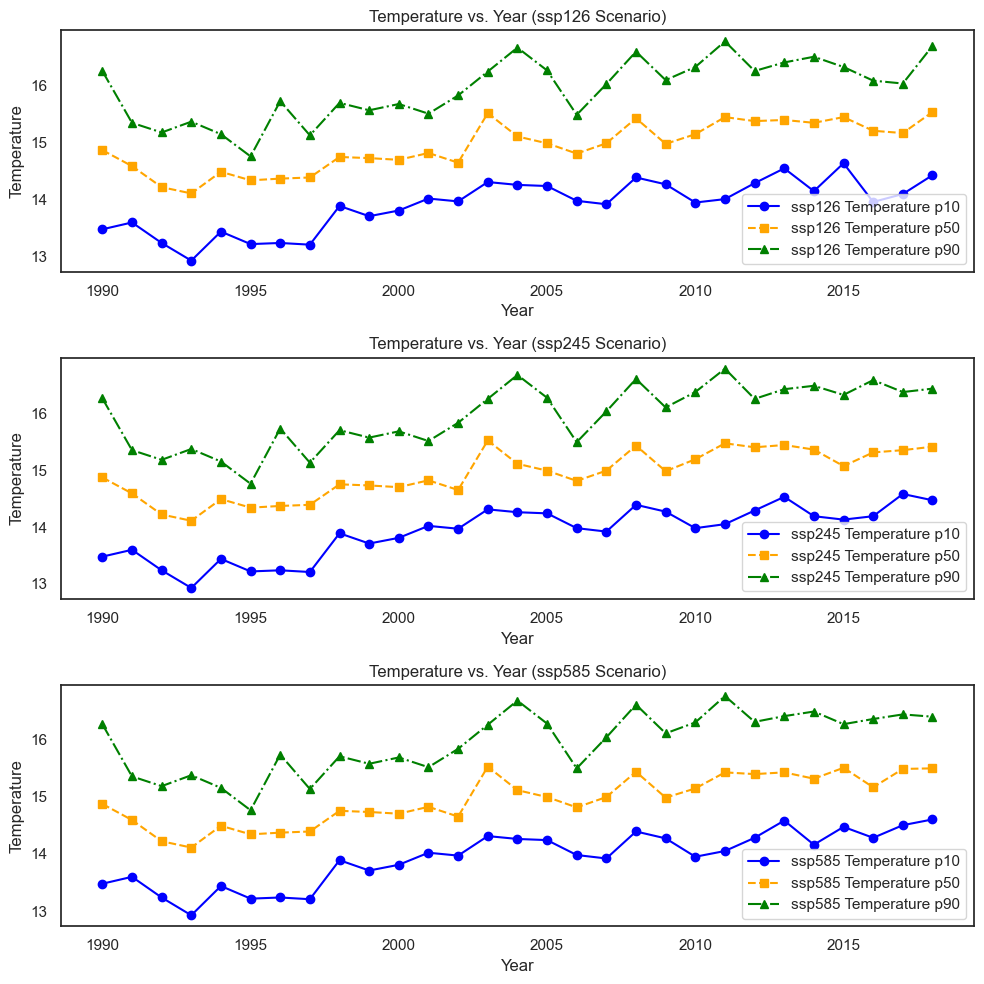

In [352]:
# Define the scenarios
scenarios = ['ssp126', 'ssp245', 'ssp585']
# Create subplots 
fig, axes = plt.subplots(3, 1, figsize=(10, 10))  
line_styles = ['-', '--', '-.']
colors = ['blue', 'orange', 'green']
markers = ['o', 's', '^']
# Iterate over each scenario
for i, scenario in enumerate(scenarios):
    # Select relevant columns for temperature in the current scenario
    temperature_p10_column = f'{scenario}_tx_mean_p10'
    temperature_p50_column = f'{scenario}_tx_mean_p50'
    temperature_p90_column = f'{scenario}_tx_mean_p90'
    # Check if the selected columns exist
    if temperature_p10_column in selected_columns:
        axes[i].plot(selected_numeric_columns['Year'], selected_numeric_columns[temperature_p10_column], 
                     label=f'{scenario} Temperature p10', linestyle=line_styles[0], color=colors[0], marker=markers[0])
    else:
        print(f"No data found for temperature p10 in {scenario} scenario.")
    
    if temperature_p50_column in selected_columns:
        axes[i].plot(selected_numeric_columns['Year'], selected_numeric_columns[temperature_p50_column], 
                     label=f'{scenario} Temperature p50', linestyle=line_styles[1], color=colors[1], marker=markers[1])
    else:
        print(f"No data found for temperature p50 in {scenario} scenario.")
    
    if temperature_p90_column in selected_columns:
        axes[i].plot(selected_numeric_columns['Year'], selected_numeric_columns[temperature_p90_column], 
                     label=f'{scenario} Temperature p90', linestyle=line_styles[2], color=colors[2], marker=markers[2])
    else:
        print(f"No data found for temperature p90 in {scenario} scenario.")

    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Temperature')
    axes[i].set_title(f'Temperature vs. Year ({scenario} Scenario)')
    axes[i].legend()
plt.tight_layout()
plt.show()


## Data exploration: Output data insights

#### measure_and_temp df

#### Relation between PM measurements and temperature scenarios

In [415]:
print(measure_and_temp)

        ID Province  Year  Polygon weight  Province %  PM 10um  PM 2.5um  \
0   959020       BC  1990        3873.793       100.0   28.825    9.8094   
1   959020       BC  1991        3805.506       100.0   29.859    9.9846   
2   959020       BC  1992        3732.484       100.0   30.558   10.2805   
3   959020       BC  1993        3659.509       100.0   31.311   10.5565   
4   959020       BC  1994        3586.492       100.0   32.163   10.8806   
5   959020       BC  1995        3513.493       100.0   33.047   11.2349   
6   959020       BC  1996        3440.472       100.0   33.856   11.5188   
7   959020       BC  1997        3373.649       100.0   33.929   11.5307   
8   959020       BC  1998        3306.804       100.0   33.916   11.5286   
9   959020       BC  1999        3239.990       100.0   33.913   11.5177   
10  959020       BC  2000        3173.179       100.0   33.858   11.4755   
11  959020       BC  2001        3170.187       100.0   33.458   11.3170   
12  959020  

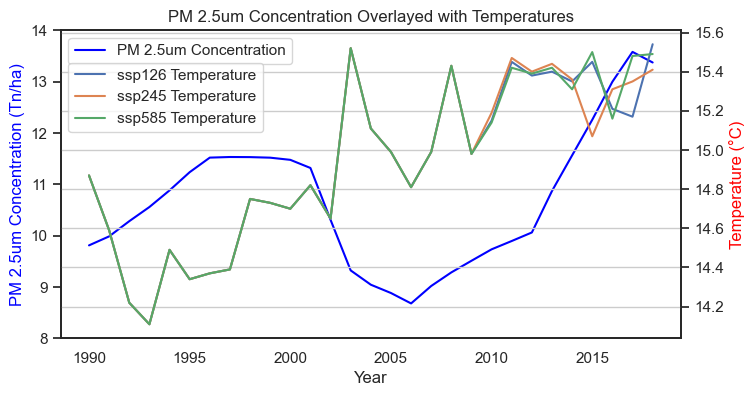

In [393]:
# Define the scenarios
scenarios = ['ssp126', 'ssp245', 'ssp585']
# Create subplots
fig, ax1 = plt.subplots(figsize=(8, 4))
# Plot PM 2.5 concentration on the first axis
ax1.plot(selected_numeric_columns['Year'], selected_numeric_columns['PM 2.5um'], color='blue', label='PM 2.5um Concentration')
ax1.set_xlabel('Year')
ax1.set_ylabel('PM 2.5um Concentration (Tn/ha)', color='blue')
ax1.set_ylim(8, 14)  # Set y-axis limits for PM 2.5 concentration
# Create a second y-axis for temperature
ax2 = ax1.twinx()
# Overlay temperatures for each scenario on the second axis
for scenario in scenarios:
    ax2.plot(selected_numeric_columns['Year'], selected_numeric_columns[f'{scenario}_tx_mean_p50'], label=f'{scenario} Temperature')
# Set labels and title for the second axis
ax2.set_ylabel('Temperature (°C)', color='red')
ax1.legend(loc='upper left')
ax2.legend(loc='upper left', bbox_to_anchor=(0, 0.92))  
plt.title('PM 2.5um Concentration Overlayed with Temperatures')
plt.grid(True)
plt.show()

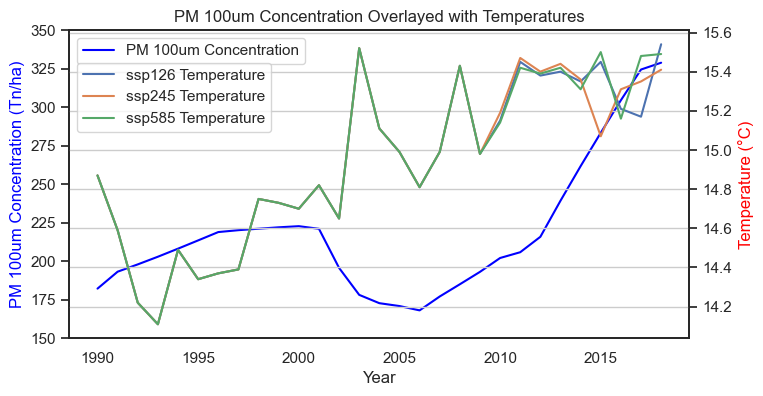

In [391]:
# Define the scenarios
scenarios = ['ssp126', 'ssp245', 'ssp585']
# Create subplots
fig, ax1 = plt.subplots(figsize=(8, 4))
# Plot PM 100um concentration on the first axis
ax1.plot(selected_numeric_columns['Year'], selected_numeric_columns['PM 100um'], color='blue', label='PM 100um Concentration')
ax1.set_xlabel('Year')
ax1.set_ylabel('PM 100um Concentration (Tn/ha)', color='blue')
ax1.set_ylim(150, 350)  # Set y-axis limits for PM 100 concentration
# Create a second y-axis for temperature
ax2 = ax1.twinx()
# Overlay temperatures for each scenario on the second axis
for scenario in scenarios:
    ax2.plot(selected_numeric_columns['Year'], selected_numeric_columns[f'{scenario}_tx_mean_p50'], label=f'{scenario} Temperature')
# Set labels and title for the second axis
ax2.set_ylabel('Temperature (°C)', color='red')
ax1.legend(loc='upper left')
ax2.legend(loc='upper left', bbox_to_anchor=(0, 0.92))  
plt.title('PM 100um Concentration Overlayed with Temperatures')
plt.grid(True)
plt.show()


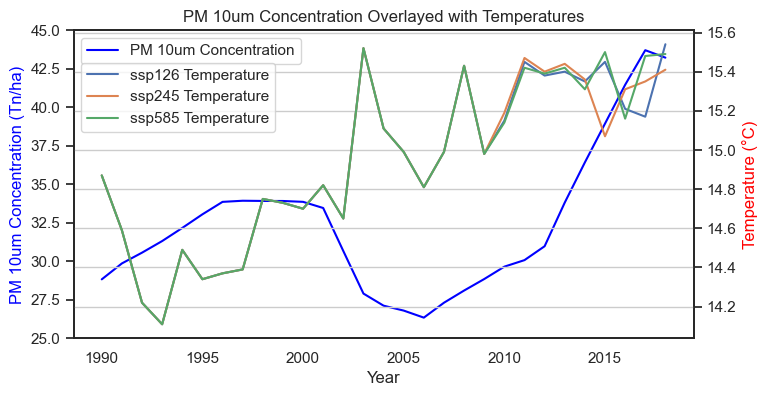

In [390]:
# Define the scenarios
scenarios = ['ssp126', 'ssp245', 'ssp585']
# Create subplots
fig, ax1 = plt.subplots(figsize=(8, 4))
# Plot PM 10um concentration on the first axis
ax1.plot(selected_numeric_columns['Year'], selected_numeric_columns['PM 10um'], color='blue', label='PM 10um Concentration')
ax1.set_xlabel('Year')
ax1.set_ylabel('PM 10um Concentration (Tn/ha)', color='blue')
ax1.set_ylim(25, 45)  # Set y-axis limits for PM 10 concentration
# Create a second y-axis for temperature
ax2 = ax1.twinx()
# Overlay temperatures for each scenario on the second axis
for scenario in scenarios:
    ax2.plot(selected_numeric_columns['Year'], selected_numeric_columns[f'{scenario}_tx_mean_p50'], label=f'{scenario} Temperature')
# Set labels and title for the second axis
ax2.set_ylabel('Temperature (°C)', color='red')
ax1.legend(loc='upper left')
ax2.legend(loc='upper left', bbox_to_anchor=(0, 0.92))  # Adjust the bbox_to_anchor to position the second legend above the first
plt.title('PM 10um Concentration Overlayed with Temperatures')
plt.grid(True)
plt.show()

## Data analysis 

#### The correlation analysis is done to understand the relationship between different variables, such as different 
#### sizes particulate matter, scenario temperatures, and other factors, such as geographic features and temporal trends.
#### The final dataset contains years, location, polygon weights and proportions, temperature values and air pollutants
#### measures.

### Correlation analysis on measure_and_temp

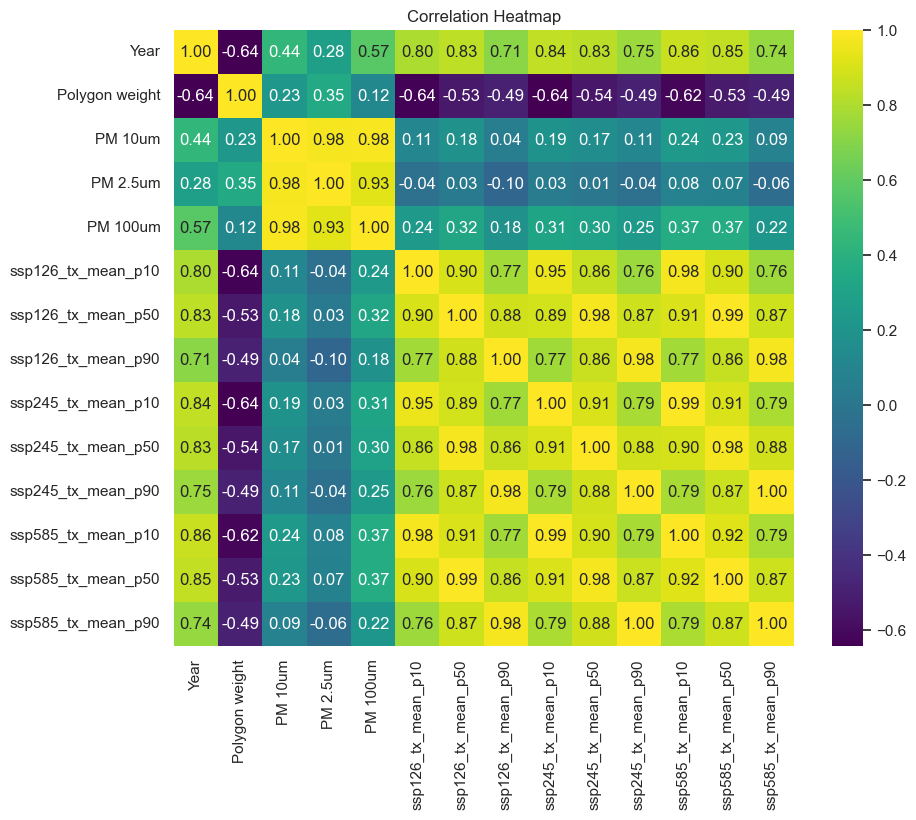

In [288]:
# Specify the columns to include in the correlation analysis
selected_columns = ['Year', 'Polygon weight', 'PM 10um', 'PM 2.5um', 'PM 100um', 'ssp126_tx_mean_p10', 'ssp126_tx_mean_p50'
                   , 'ssp126_tx_mean_p90', 'ssp245_tx_mean_p10', 'ssp245_tx_mean_p50', 'ssp245_tx_mean_p90',
                    'ssp585_tx_mean_p10', 'ssp585_tx_mean_p50', 'ssp585_tx_mean_p90']  

selected_numeric_columns = measure_and_temp[selected_columns]
# Calculate the correlation matrix
correlation_matrix = selected_numeric_columns.corr()
# Create a heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [289]:
# Iterate over the correlation matrix
for column1 in correlation_matrix.columns:
    for column2 in correlation_matrix.columns:
        # Print the correlation coefficient for the pair of columns
        print(f"Correlation between {column1} and {column2}: {correlation_matrix.loc[column1, column2]}")

Correlation between Year and Year: 1.0
Correlation between Year and Polygon weight: -0.6433071699593201
Correlation between Year and PM 10um: 0.4412949522504501
Correlation between Year and PM 2.5um: 0.2769997043843772
Correlation between Year and PM 100um: 0.5743987897277943
Correlation between Year and ssp126_tx_mean_p10: 0.8005321906961171
Correlation between Year and ssp126_tx_mean_p50: 0.8334252444636487
Correlation between Year and ssp126_tx_mean_p90: 0.7117481606517625
Correlation between Year and ssp245_tx_mean_p10: 0.8397113742305603
Correlation between Year and ssp245_tx_mean_p50: 0.8273815119247776
Correlation between Year and ssp245_tx_mean_p90: 0.7502138905943262
Correlation between Year and ssp585_tx_mean_p10: 0.8602393691834981
Correlation between Year and ssp585_tx_mean_p50: 0.847155140871415
Correlation between Year and ssp585_tx_mean_p90: 0.738019808897568
Correlation between Polygon weight and Year: -0.6433071699593201
Correlation between Polygon weight and Polygon w

#### It is seen in violet the strong correlation, in green the intermediate correlation and in yellow the low correlation.
#### Bellow the correlation analysis, the correlations coeffients were printed.
#### In order to futher analyze the air pollution data, a regression analysis is performed.
#### The aim of this project is to find patterns between the 100 um PM measurements and the temperatures. 

### Visualize max_temp over the years and PM measurements

C:\Users\User\AppData\Local\Temp\ipykernel_30220\386287404.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


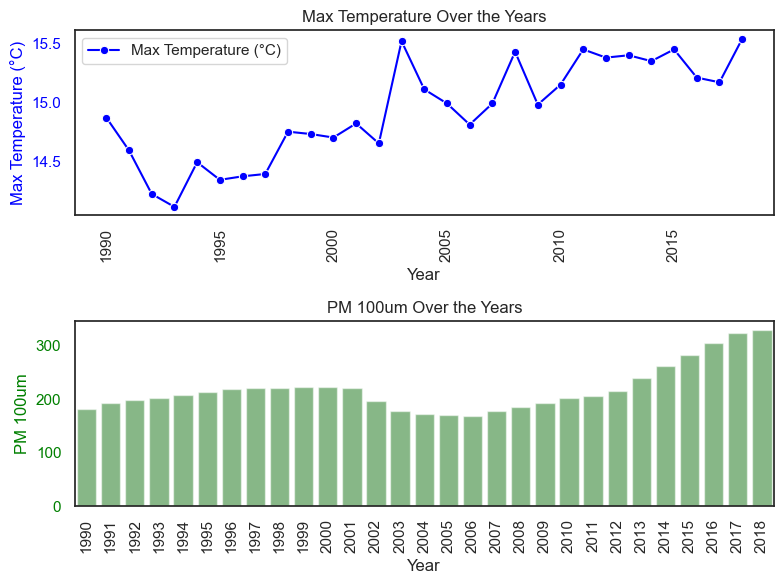

In [310]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
# Plot temperature data as a line plot
sns.lineplot(data=measure_and_temp, x='Year', y='ssp126_tx_mean_p50', ax=ax1, label='Max Temperature (°C)', color='blue', marker='o')
ax1.set_xlabel('Year')
ax1.set_ylabel('Max Temperature (°C)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Max Temperature Over the Years')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
# Plot PM 100 um data as a bar plot
sns.barplot(data=measure_and_temp, x='Year', y='PM 100um', ax=ax2, color='green', alpha=0.5)
ax2.set_xlabel('Year')
ax2.set_ylabel('PM 100um', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_title('PM 100um Over the Years')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

#### From the data, it is seen that low PM measures have been taken when the temperature was low, and
#### high PM measurements have been taken when the temperature was high.But, in the last years this pattern 
#### has changed and high PM measures have been taken when T is high.
#### It is important to highlight that the data is filter for one polygon location (Abbotsford, BC) over the years (1990-2018). 

### Regression Analysis 

#### Check the model in ssp126

In [434]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
# Define independent variables (X=features) and dependent variable (y=target)
X = selected_numeric_columns[['Year', 'Polygon weight', 'PM 10um', 'PM 2.5um', 'ssp126_tx_mean_p10', 'ssp126_tx_mean_p50'
                   , 'ssp126_tx_mean_p90']]
y = selected_numeric_columns['PM 100um']  
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize and fit the regression model
model = LinearRegression()
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
# Get the coefficients of the model
coefficients = model.coef_
intercept = model.intercept_
print("Coefficients:", coefficients)
print("Intercept:", intercept)
# Calculate R-squared
r_squared = r2_score(y_test, y_pred)
print("R-squared:", r_squared)

Mean Squared Error: 6.321779655040836
Coefficients: [ 5.57820878e-01  4.81892221e-03  1.38040900e+01 -1.84597363e+01
 -7.99910238e-01 -8.10852282e-01  1.03904891e+00]
Intercept: -1157.95255673279
R-squared: 0.9973101454096709


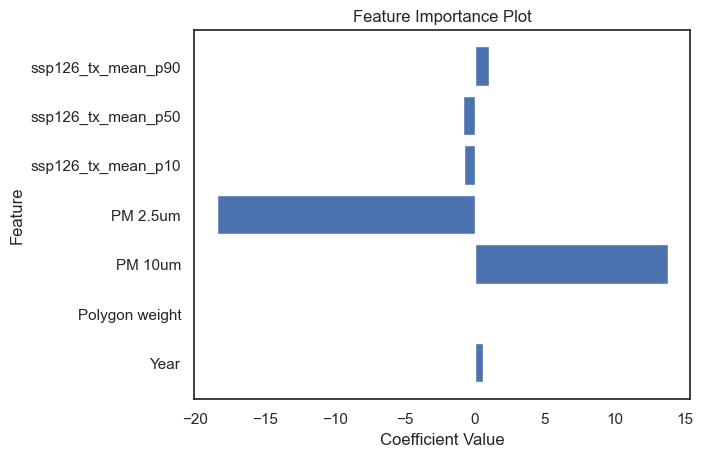

In [435]:
feature_names = ['Year', 'Polygon weight', 'PM 10um', 'PM 2.5um', 'ssp126_tx_mean_p10', 'ssp126_tx_mean_p50'
                   , 'ssp126_tx_mean_p90']
plt.barh(feature_names, coefficients)
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance Plot")
plt.show()


#### Check the model in ssp245

In [436]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
# Define independent variables (X=features) and dependent variable (y=target)
X = selected_numeric_columns[['Year', 'Polygon weight', 'PM 10um', 'PM 2.5um', 'ssp245_tx_mean_p10', 'ssp245_tx_mean_p50'
                   , 'ssp245_tx_mean_p90']]
y = selected_numeric_columns['PM 100um']  
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize and fit the regression model
model = LinearRegression()
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
# Get the coefficients of the model
coefficients = model.coef_
intercept = model.intercept_
print("Coefficients:", coefficients)
print("Intercept:", intercept)
# Calculate R-squared
r_squared = r2_score(y_test, y_pred)
print("R-squared:", r_squared)

Mean Squared Error: 5.835306652830069
Coefficients: [ 5.71517684e-01  4.99807086e-03  1.39001944e+01 -1.89284241e+01
 -6.42327668e-01  6.26627093e-01 -5.51636504e-01]
Intercept: -1182.3293359508484
R-squared: 0.9975171348508521


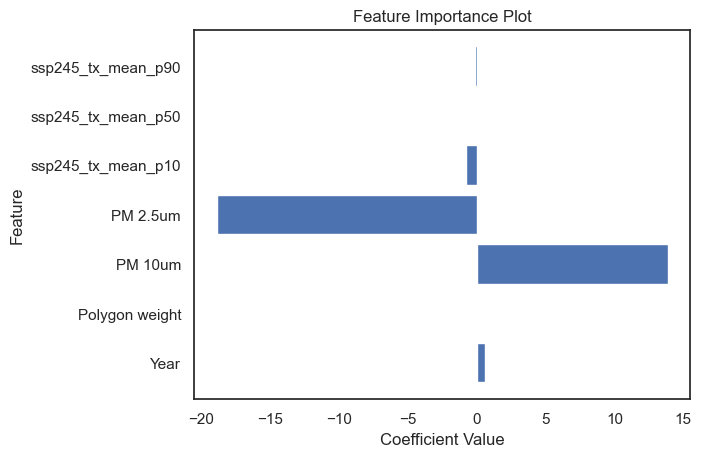

In [439]:
feature_names = ['Year', 'Polygon weight', 'PM 10um', 'PM 2.5um', 'ssp245_tx_mean_p10', 'ssp245_tx_mean_p50'
                   , 'ssp245_tx_mean_p90']
plt.barh(feature_names, coefficients)
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance Plot")
plt.show()

C:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


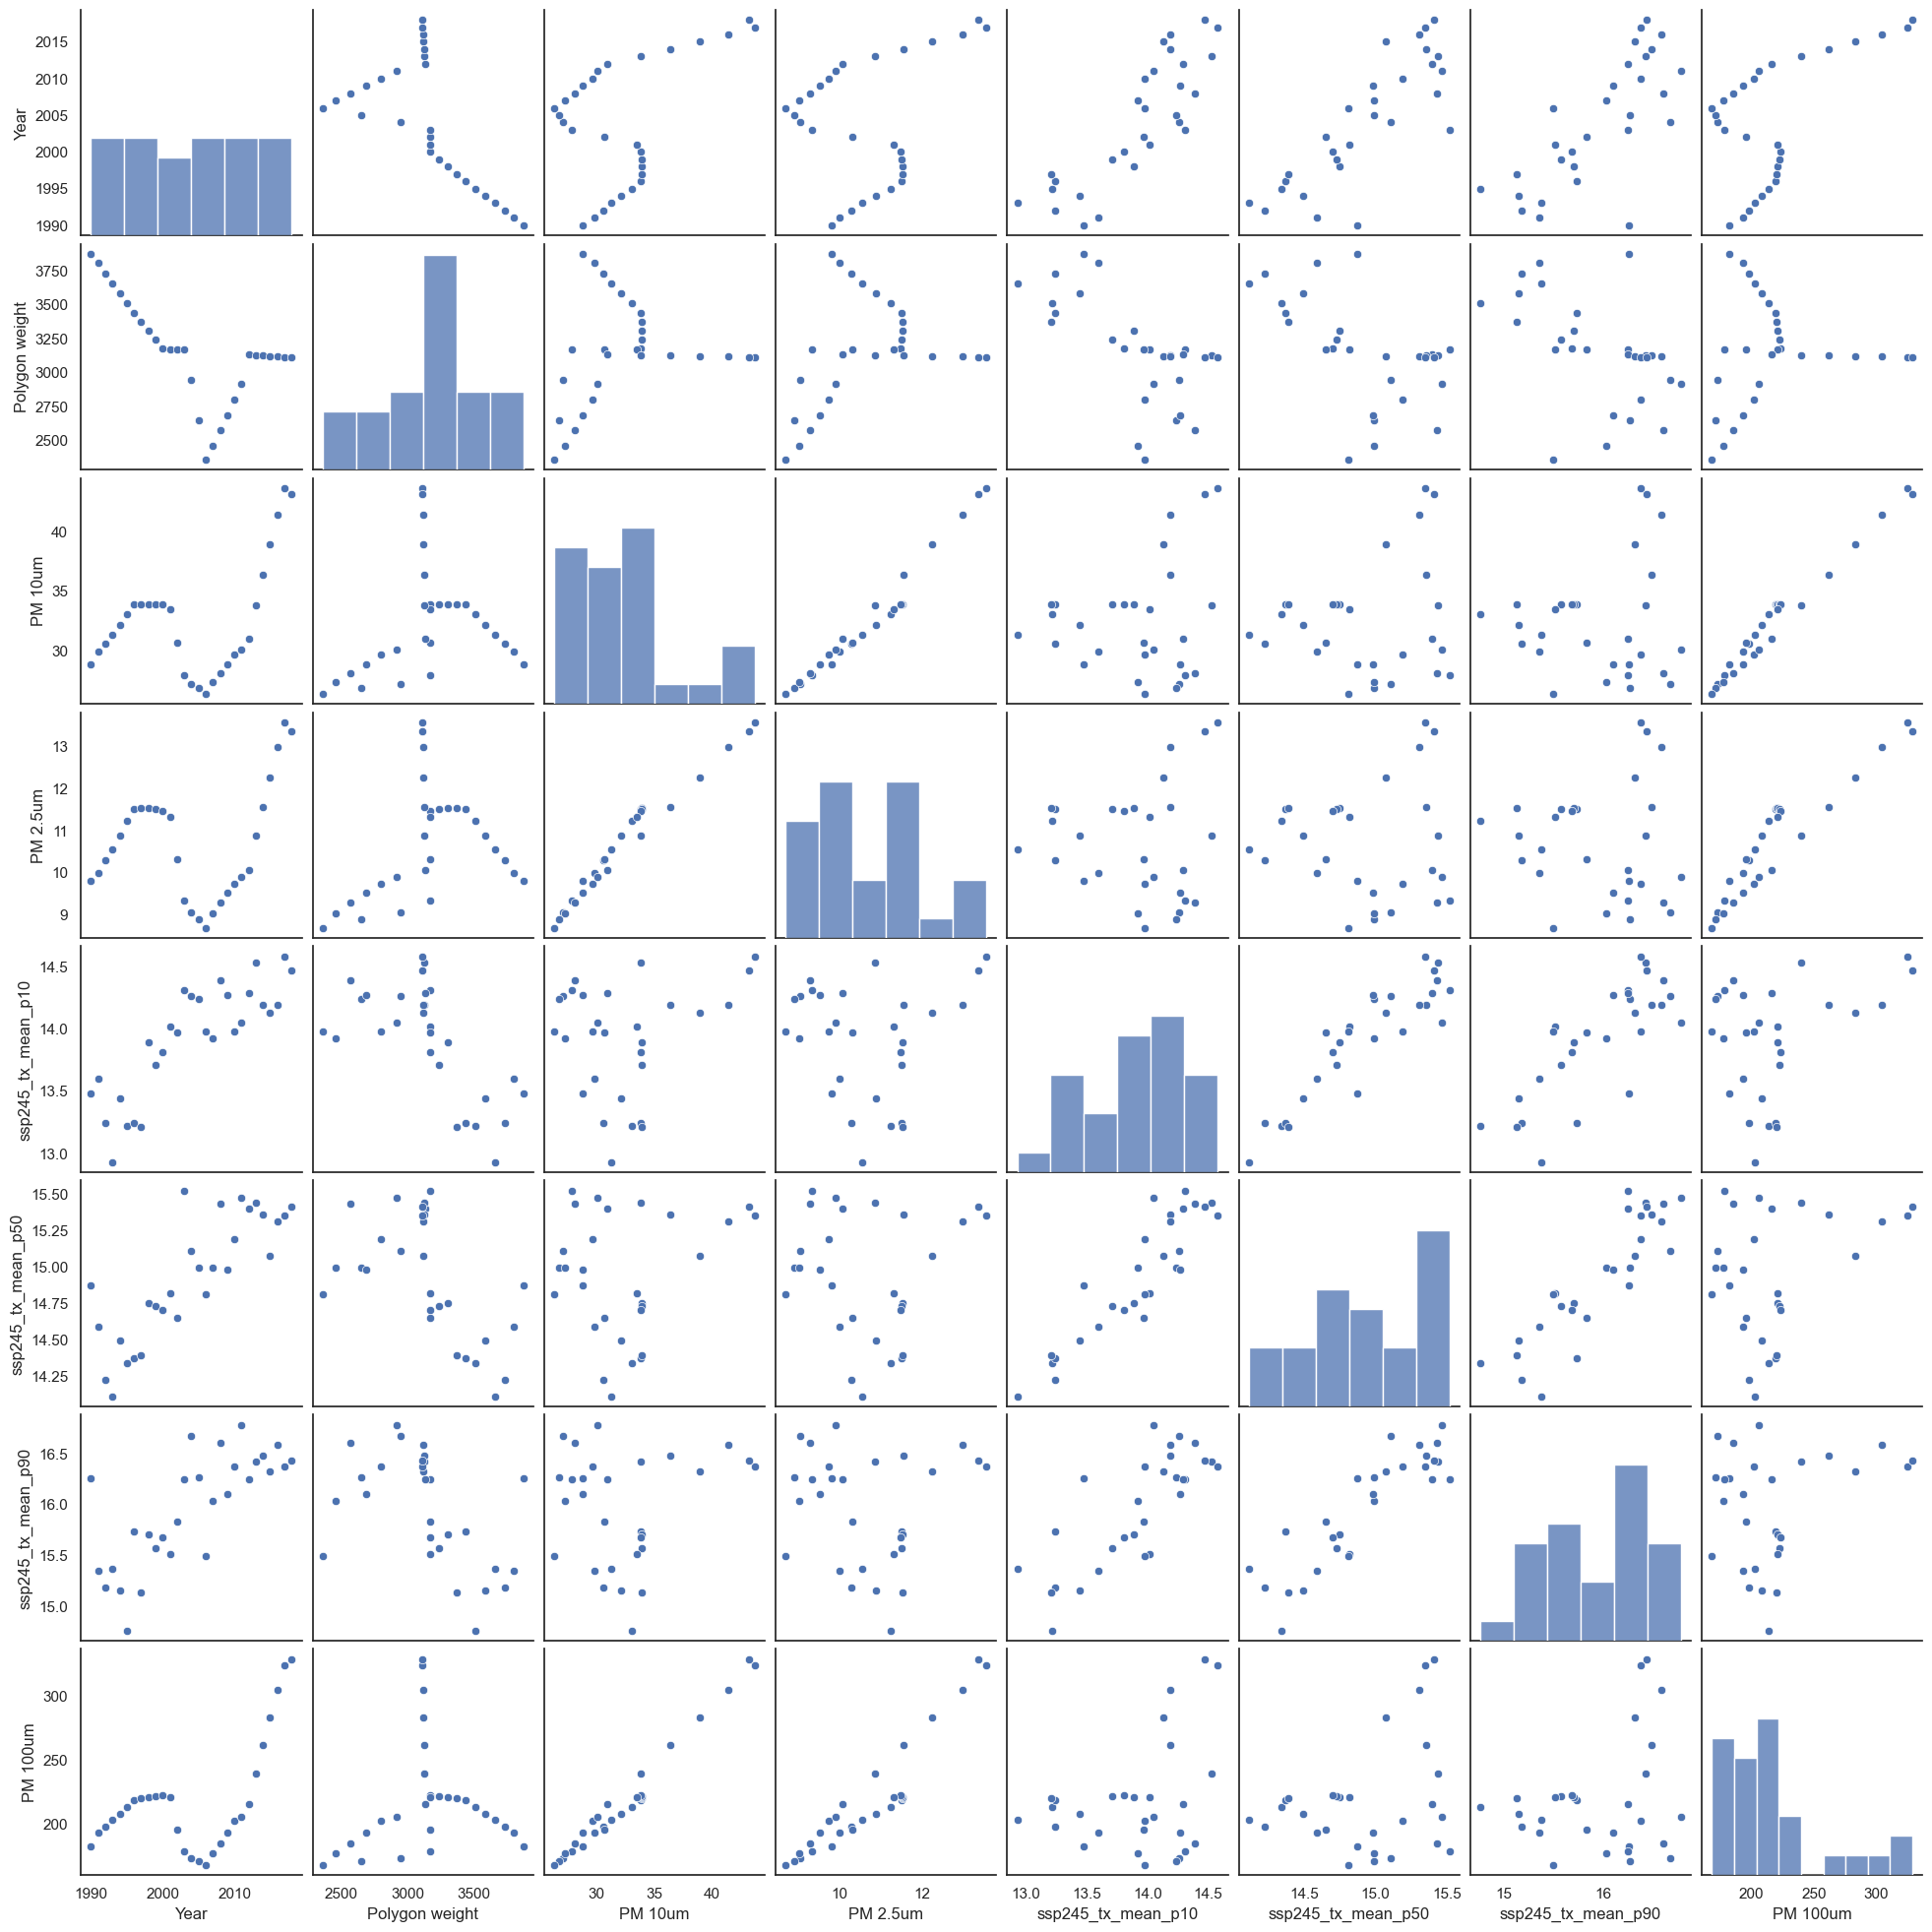

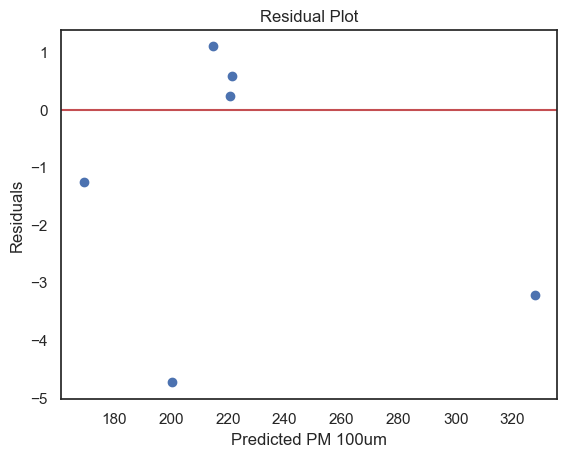

In [440]:
import seaborn as sns
import matplotlib.pyplot as plt
# Pairplot
sns.pairplot(selected_numeric_columns[['Year', 'Polygon weight', 'PM 10um', 'PM 2.5um', 'ssp245_tx_mean_p10', 'ssp245_tx_mean_p50', 'ssp245_tx_mean_p90', 'PM 100um']])
plt.show()
# Residual plot
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted PM 100um')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Residual Plot')
plt.show()

#### Prediction: 
#### With the values year:2035, Polygon weight:100, PM 10um:30 Tn/ha, PM 2.5um:8 Tn/ha,
#### ssp245_tx_mean_p10: 13.5 C, ssp245_tx_mean_p50: 15 C and ssp245_tx_mean_p90: 15.5 C.
#### Which would be the value for PM 100um given those conditions?

In [444]:
# Sample input data for prediction
sample_data = [[2025, 100, 30, 8, 13.5, 15, 15.5]]
# Make prediction
predicted_value = model.predict(sample_data)
print("Predicted PM 100um:", predicted_value)

Predicted PM 100um: [233.04274736]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#### Trying a set of higher temperatures shows lower PM 100 air concentrations.

In [446]:
# Sample input data for prediction
sample_data = [[2025, 100, 30, 8, 18.5, 19, 19.5]]
# Make prediction
predicted_value = model.predict(sample_data)
print("Predicted PM 100um:", predicted_value)

Predicted PM 100um: [228.33594934]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#### And finally having a set of lower temperatures shows high levels of PM 100 air concentration.

In [447]:
# Sample input data for prediction
sample_data = [[2025, 100, 30, 8, 10.5, 11, 11.5]]
# Make prediction
predicted_value = model.predict(sample_data)
print("Predicted PM 100um:", predicted_value)

Predicted PM 100um: [236.15678781]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#### Check the model for ssp585

In [437]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
# Define independent variables (X=features) and dependent variable (y=target)
X = selected_numeric_columns[['Year', 'Polygon weight', 'PM 10um', 'PM 2.5um', 'ssp585_tx_mean_p10', 'ssp585_tx_mean_p50'
                   , 'ssp585_tx_mean_p90']]
y = selected_numeric_columns['PM 100um'] 
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize and fit the regression model
model = LinearRegression()
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
# Get the coefficients of the model
coefficients = model.coef_
intercept = model.intercept_
print("Coefficients:", coefficients)
print("Intercept:", intercept)
# Calculate R-squared
r_squared = r2_score(y_test, y_pred)
print("R-squared:", r_squared)

Mean Squared Error: 6.009464776331253
Coefficients: [ 5.95177500e-01  5.14438983e-03  1.38787623e+01 -1.88813894e+01
 -7.96378785e-01 -6.61777798e-02 -1.15048244e-01]
Intercept: -1224.4908556561406
R-squared: 0.9974430322953212


### Random Forest Regressor

#### Check for ssp126

In [431]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
# Define independent variables (X=features) and dependent variable (y=target)
X = selected_numeric_columns[['Year', 'Polygon weight', 'PM 10um', 'PM 2.5um', 'ssp126_tx_mean_p10', 'ssp126_tx_mean_p50'
                   , 'ssp126_tx_mean_p90']]
y = selected_numeric_columns['PM 100um']  
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize and fit the regression model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
# Calculate R-squared
r_squared = r2_score(y_test, y_pred)
print("R-squared:", r_squared)

Mean Squared Error: 101.0475137827175
R-squared: 0.9570052843311214


#### Check for ssp245

In [432]:
# Define independent variables (X=features) and dependent variable (y=target)
X = selected_numeric_columns[['Year', 'Polygon weight', 'PM 10um', 'PM 2.5um', 'ssp245_tx_mean_p10', 'ssp245_tx_mean_p50'
                   , 'ssp245_tx_mean_p90']]
y = selected_numeric_columns['PM 100um']  
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize and fit the regression model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
# Calculate R-squared
r_squared = r2_score(y_test, y_pred)
print("R-squared:", r_squared)

Mean Squared Error: 79.1774926088837
R-squared: 0.9663107615946517


#### Check for ssp585

In [433]:
# Define independent variables (X=features) and dependent variable (y=target)
X = selected_numeric_columns[['Year', 'Polygon weight', 'PM 10um', 'PM 2.5um', 'ssp585_tx_mean_p10', 'ssp585_tx_mean_p50'
                   , 'ssp585_tx_mean_p90']]
y = selected_numeric_columns['PM 100um']  
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize and fit the regression model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
# Calculate R-squared
r_squared = r2_score(y_test, y_pred)
print("R-squared:", r_squared)

Mean Squared Error: 82.18898459196711
R-squared: 0.9650294016016666


#### For the regression analysis, the Linear Regression model performs better than the Random Forest Regressor
#### for this dataset. According to both models, the ssp245 is which best fits the data.

## Project conclusion

 Particulate matter concentrations PM 2.5um , PM 10um, PM 100um are influenced by various environmental factors,
 including temperature. Temperature can affect the dispersion, chemical reactions, and physical processes 
 like evaporation and condensation of particulate matter in the atmosphere. 
 Therefore, including temperature as an independent variable and performing regression analysis allows to account for the    potential influence of the temperature on PM concentrations.
 
Based on the analysis results and considering the relationship between PM 100um particulate matter concentrations in the air and the temperature variations, the following conclusion arise:

1- The predictive model developed demonstrates a strong capability to estimate PM 100um concentrations based on various environmental factors, including temperature. 

2- The observed behavior of the model aligns with expectations regarding the impact of temperature on particulate matter concentrations.

3- Firstly, when temperatures are higher, as indicated by the input features ssp245_tx_mean_p10, ssp245_tx_mean_p50, and ssp245_tx_mean_p90, the model predicts lower PM 100um concentrations. This outcome corresponds with existing scientific understanding, as higher temperatures can enhance atmospheric mixing and dispersion, leading to lower concentrations of particulate matter.

4- Conversely, when temperatures are lower, the model predicts higher PM 100um concentrations. This relationship is consistent with the tendency for colder temperatures to decrease atmospheric mixing and dispersion, thereby allowing particulate matter to accumulate and persist in the air.

These findings underscore the intricate interplay between meteorological variables, such as temperature, and air quality parameters like particulate matter concentrations. Understanding these relationships is crucial for effective environmental management and public health interventions, especially in the context of climate change, where temperature variations may become more pronounced.

In summary, this project analysis highlights the significant impact of temperature variations on particulate matter concentrations in the air. By leveraging predictive modeling techniques, we can gain valuable insights into these relationships, aiding in the development of strategies to mitigate air pollution and safeguard public health in a changing climate.

# End